# Part 1: investigating and filtering inconsistencies.

If you are not interested in how the inconsistencies in kg values were investigated, you can go to part 2: transport routes and prices analysis.

In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import seaborn as sns
import networkx as nx
import copy
load_dotenv()
print(os.getenv("COMTRADE_API_KEY"))

d4457e079e6240cc8f74def00b4e192f


In [2]:
nat_gas_codes = {271111: 'Natural gas, liquefied',
                 271121: 'Natural gas, gaseous'}

year_list = list(range(2010, datetime.now().year)) # list of all years from 2000 to now


In [ ]:
dfr = pd.read_csv("data/processed/comtrade_natural_gas_clean.csv") 

print(dfr.shape)
dfr.sample(5).style

(91723, 28)


,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,qtyUnitCode,qty,isQtyEstimated,altQtyUnitCode,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,primaryValue,isAggregate,reporter,partner,customs_type,transport,qty_type,alt_qty_type,type,flow
64505,2021-12-01,2021,12,442,M,568,H5,271111,C20,1000,8,28.487000,False,18,15.269000,False,28.487000,False,12.559000,False,Luxembourg,"Europe, not elsewhere specified",CPC N.E.S.,Air,kg,Terajoule (gross calorific value),liquefied,Import
76378,2023-07-01,2023,7,410,X,36,H6,271121,C00,0,8,2.000000,False,8,2.000000,False,2.000000,False,2.000000,False,Republic of Korea,Australia,TOTAL CPC,Total Modes of Transport,kg,Weight in kilograms,gaseous,Export
67279,2022-04-01,2022,4,752,M,579,H6,271111,C00,2100,8,9100000.000000,False,18,553.000000,False,9100000.000000,False,19746552.369000,False,Sweden,Norway,TOTAL CPC,Sea,kg,Terajoule (gross calorific value),liquefied,Import
62423,2021-09-01,2021,9,191,M,705,H5,271121,C00,0,8,10504500.000000,False,18,589.659000,False,10504500.000000,False,4332476.000000,False,Croatia,Slovenia,TOTAL CPC,Total Modes of Transport,kg,Terajoule (gross calorific value),gaseous,Import
64563,2021-12-01,2021,12,528,M,899,H5,271111,C00,0,8,345060.000000,False,18,18.000000,False,345060.000000,False,484581.856000,False,Netherlands,"Areas, not elsewhere specified",TOTAL CPC,Total Modes of Transport,kg,Terajoule (gross calorific value),liquefied,Import


In [4]:
dfr.groupby(['refYear', 'flow', 'type'])[['primaryValue', 'netWgt']].agg('sum').tail(20)
#total import and export in dollars and in kg in billions for each form of gas

primaryValue        netWgt
refYear flow   type                                 
2021    Export gaseous    1.411787e+11  3.488699e+11
               liquefied  1.007133e+11  2.235062e+11
        Import gaseous    1.920918e+11  6.210057e+13
               liquefied  1.748342e+11  7.246524e+11
2022    Export gaseous    3.108296e+11  3.109447e+11
               liquefied  1.642181e+11  1.741268e+11
        Import gaseous    3.718893e+11  6.032037e+13
               liquefied  3.634238e+11  3.546971e+11
2023    Export gaseous    1.449323e+11  2.315073e+11
               liquefied  1.336496e+11  1.848882e+11
        Import gaseous    2.019757e+11  6.598796e+13
               liquefied  2.516039e+11  3.585172e+11
2024    Export gaseous    1.076077e+11  2.074444e+11
               liquefied  1.068541e+11  1.842317e+11
        Import gaseous    1.459781e+11  6.652323e+13
               liquefied  2.062007e+11  3.679610e+11
2025    Export gaseous    9.310529e+10  1.604500e+11
               liquefied  8.625172e+10  1.583214e+11
        Import gaseous    1.044884e+11  5.794974e+13
               liquefied  9.957010e+10  1.690311e+11

We see huge discrepancies in netWgt (traded gas measured in kg) in gaseous (and in liquified as appeared but smaller) form of gas starting from 2015 - netWgt needs filtering to use. Difference in export and import is expected - countries export goods with much lower prices then others import these goods. But difference in kg values is unreasonable.

In [21]:
dfr[(dfr.flow == 'Import') & (dfr.refYear >= 2022)].groupby('refYear')['netWgt'].nlargest(5)/10**9

refYear       
2022     68211    5376.6699
         69441    5314.2845
         68841    5301.1480
         67656    5189.6423
         70074    5026.8496
2023     77041    6105.3000
         76404    5960.8300
         78386    5794.1700
         77650    5713.5000
         75727    5705.4100
2024     82888    7144.8200
         84574    6012.3800
         85150    5977.8800
         83988    5799.6900
         83426    5597.9700
2025     89899    6313.0400
         90777    6282.2000
         90348    6076.5800
         91217    6067.2300
         89370    5832.0600
Name: netWgt, dtype: float64

In [6]:
bad_rows_g = dfr[ (dfr.cmdCode == 271121) & (dfr.flow == 'Import') & (dfr.refYear >= 2015)].groupby('refYear')['netWgt'].nlargest(7).index
bad_indexes_g = []
for i in range(len(bad_rows_g)):
    bad_indexes_g.append(bad_rows_g[i][1])      #getting indexes of these countries with crazy amounts of volume of trade in kg (7 just to see)


In [22]:
needed_cols = ['type', 'period', 'reporter', 'flow', 'partner', 'cmdCode', 'primaryValue', 'qty', 'qty_type', 'netWgt', 'altQty', 'alt_qty_type']
dfr.loc[bad_indexes_g, needed_cols].head(10)

,type,period,reporter,flow,partner,cmdCode,primaryValue,qty,qty_type,netWgt,altQty,alt_qty_type
25801,gaseous,2015-09-01,Mexico,Import,United States of America,271121,291450934.0,2.934170e+12,kg,2.934170e+12,2.934170e+12,Volume in liters
25517,gaseous,2015-08-01,Mexico,Import,United States of America,271121,304850070.0,2.903460e+12,kg,2.903460e+12,2.903460e+12,Volume in liters
26878,gaseous,2015-11-01,Mexico,Import,United States of America,271121,257669194.0,2.901270e+12,kg,2.901270e+12,2.901270e+12,Volume in liters
26470,gaseous,2015-10-01,Mexico,Import,United States of America,271121,277836551.0,2.893250e+12,kg,2.893250e+12,2.893250e+12,Volume in liters
24720,gaseous,2015-07-01,Mexico,Import,United States of America,271121,268294751.0,2.680870e+12,kg,2.680870e+12,2.680870e+12,Volume in liters
27392,gaseous,2015-12-01,Mexico,Import,United States of America,271121,207058063.0,2.673160e+12,kg,2.673160e+12,2.673160e+12,Volume in liters
24415,gaseous,2015-06-01,Mexico,Import,United States of America,271121,251090743.0,2.574400e+12,kg,2.574400e+12,2.574400e+12,Volume in liters
31120,gaseous,2016-09-01,Mexico,Import,United States of America,271121,339791979.0,3.765060e+12,kg,3.765060e+12,3.765060e+12,Volume in liters
31791,gaseous,2016-11-01,Mexico,Import,United States of America,271121,370893653.0,3.591800e+12,kg,3.591800e+12,3.591800e+12,Volume in liters
31456,gaseous,2016-10-01,Mexico,Import,United States of America,271121,364762496.0,3.572070e+12,kg,3.572070e+12,3.572070e+12,Volume in liters


In [8]:
bad_rows_l = dfr[ (dfr.cmdCode == 271111) & (dfr.flow == 'Import') & (dfr.refYear >= 2015)].groupby('refYear')['netWgt'].nlargest(4).index
bad_indexes_l = []
for i in range(len(bad_rows_l)):
    bad_indexes_l.append(bad_rows_l[i][1])  #the same for liquified (it appeared there are also discrepancies - smaller than in gaseous so difficult to notice)

In [23]:
dfr.loc[bad_indexes_l, needed_cols].head(10)

,type,period,reporter,flow,partner,cmdCode,primaryValue,qty,qty_type,netWgt,altQty,alt_qty_type
21955,liquefied,2015-01-01,Mexico,Import,United States of America,271111,14471911.0,3.930460e+11,kg,3.930460e+11,3.930460e+11,Volume in liters
25799,liquefied,2015-09-01,Mexico,Import,United States of America,271111,11913002.0,1.106620e+11,kg,1.106620e+11,1.106620e+11,Volume in liters
24718,liquefied,2015-07-01,Mexico,Import,United States of America,271111,10297115.0,9.980890e+10,kg,9.980890e+10,9.980890e+10,Volume in liters
26876,liquefied,2015-11-01,Mexico,Import,United States of America,271111,8870740.0,9.531260e+10,kg,9.531260e+10,9.531260e+10,Volume in liters
28193,liquefied,2016-02-01,Mexico,Import,United States of America,271111,8791332.0,1.012530e+11,kg,1.012530e+11,1.012530e+11,Volume in liters
27906,liquefied,2016-01-01,Mexico,Import,United States of America,271111,8387527.0,9.964180e+10,kg,9.964180e+10,9.964180e+10,Volume in liters
30581,liquefied,2016-08-01,Mexico,Import,United States of America,271111,9581312.0,9.754310e+10,kg,9.754310e+10,9.754310e+10,Volume in liters
30322,liquefied,2016-07-01,Mexico,Import,United States of America,271111,8779755.0,9.556980e+10,kg,9.556980e+10,9.556980e+10,Volume in liters
35852,liquefied,2017-08-01,Mexico,Import,United States of America,271111,8532691.0,7.707790e+10,kg,7.707790e+10,7.707790e+10,Volume in liters
36328,liquefied,2017-09-01,Mexico,Import,United States of America,271111,7796407.0,7.535960e+10,kg,7.535960e+10,7.535960e+10,Volume in liters


In [10]:
bad_rows = dfr[(dfr.flow == 'Import') & (dfr.refYear >= 2015)].groupby('refYear')['netWgt'].nlargest(4).index
bad_indexes = []
for i in range(len(bad_rows)):
    bad_indexes.append(bad_rows[i][1]) 

dfr.loc[bad_indexes, needed_cols].head(10)

,type,period,reporter,flow,partner,cmdCode,primaryValue,qty,qty_type,netWgt,altQty,alt_qty_type
25801,gaseous,2015-09-01,Mexico,Import,United States of America,271121,291450934.0,2.934170e+12,kg,2.934170e+12,2.934170e+12,Volume in liters
25517,gaseous,2015-08-01,Mexico,Import,United States of America,271121,304850070.0,2.903460e+12,kg,2.903460e+12,2.903460e+12,Volume in liters
26878,gaseous,2015-11-01,Mexico,Import,United States of America,271121,257669194.0,2.901270e+12,kg,2.901270e+12,2.901270e+12,Volume in liters
26470,gaseous,2015-10-01,Mexico,Import,United States of America,271121,277836551.0,2.893250e+12,kg,2.893250e+12,2.893250e+12,Volume in liters
31120,gaseous,2016-09-01,Mexico,Import,United States of America,271121,339791979.0,3.765060e+12,kg,3.765060e+12,3.765060e+12,Volume in liters
31791,gaseous,2016-11-01,Mexico,Import,United States of America,271121,370893653.0,3.591800e+12,kg,3.591800e+12,3.591800e+12,Volume in liters
31456,gaseous,2016-10-01,Mexico,Import,United States of America,271121,364762496.0,3.572070e+12,kg,3.572070e+12,3.572070e+12,Volume in liters
30580,gaseous,2016-08-01,Mexico,Import,United States of America,271121,298917759.0,3.407060e+12,kg,3.407060e+12,3.407060e+12,Volume in liters
36726,gaseous,2017-10-01,Mexico,Import,United States of America,271121,510781798.0,4.341230e+12,kg,4.341230e+12,4.341230e+12,Volume in liters
36331,gaseous,2017-09-01,Mexico,Import,United States of America,271121,527838629.0,3.973390e+12,kg,3.973390e+12,3.973390e+12,Volume in liters


In [11]:
dfr_kg = dfr[ ~( (dfr.refYear >= 2015) & 
                 (dfr.reporter == 'Mexico') & (dfr.flow == 'Import') & (dfr.partner == 'United States of America') )]
dfr_kg.shape, dfr.shape

((91408, 28), (91723, 28))

In [12]:
dfr_kg[dfr_kg.refYear >= 2021].groupby(['refYear', 'flow', 'cmdCode'])[['primaryValue', 'netWgt']].agg('sum')/10**9

primaryValue      netWgt
refYear flow   cmdCode                          
2021    Export 271111     100.713302  223.506228
               271121     141.178720  348.869936
        Import 271111     174.717343  333.746783
               271121     180.174352  399.662271
2022    Export 271111     164.218069  174.126765
               271121     310.829622  310.944718
        Import 271111     363.323064  354.438865
               271121     358.329844  288.721132
2023    Export 271111     133.649575  184.888238
               271121     144.932257  231.507286
        Import 271111     251.487759  358.226937
               271121     195.365725  274.907155
2024    Export 271111     106.854108  184.231717
               271121     107.607683  207.444403
        Import 271111     206.199806  366.231729
               271121     141.272699  266.619638
2025    Export 271111      86.251724  158.321401
               271121      93.105295  160.449964
        Import 271111      99.570104  169.031146
               271121      98.228916  165.963051

We see a common pattern: there is a mistake in registering value in kg of import of gaseous and liquified natural gas from USA to Mexico - so I created one more df without these trades and everything seems logical (it is likely that they write value in liters to value in kg since value in liters has the same value). However, trade value in dollars between countries corresponds to reality - I checked in public databases. So I will use for dollar analysis dfr (main df) and for analysis in kg I will use dfr_kg.

In [13]:
def plot_trades(column:str, measure: str, df=dfr):
    for i in range(2):
        for fl in ['Export', 'Import']:
            plt.figure(figsize=(10,3))
            (df[(df.flow == fl) & (df.cmdCode == list(nat_gas_codes.keys())[i] )].groupby('refYear')[column].sum()/10**9).plot.bar()
            plt.title(nat_gas_codes[ list(nat_gas_codes.keys())[i] ] + '; ' + str(column) + ', Total ' + str(fl))
            plt.xlabel('Years')
            plt.ylabel('Total ' +str(fl) + ', billions of ' +str(measure))
            plt.grid(True, alpha=0.5)

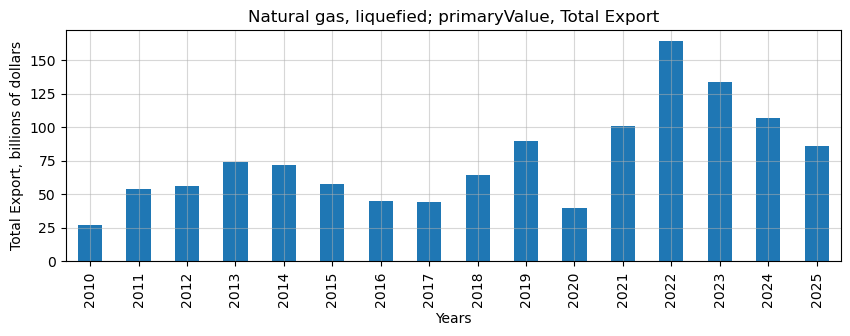

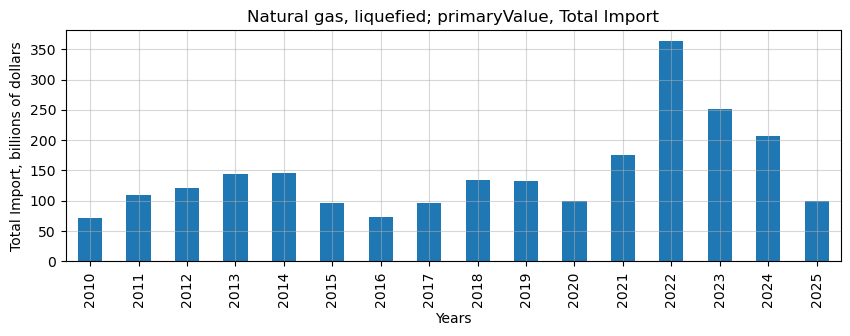

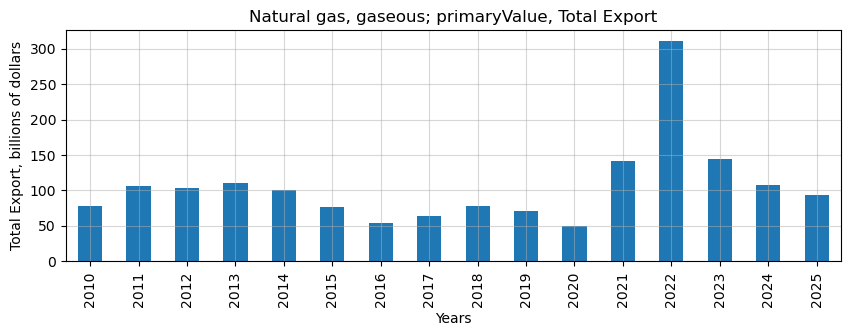

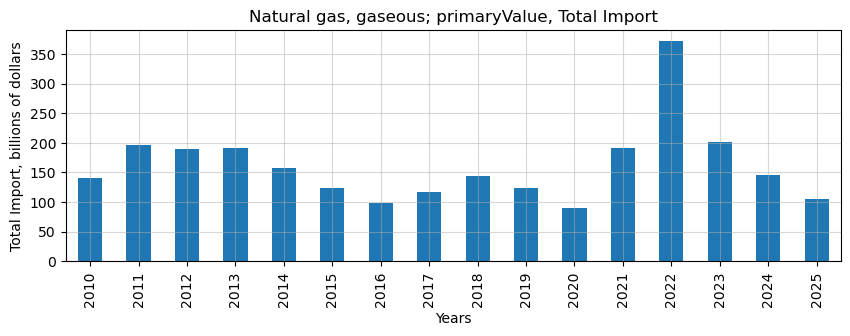

In [14]:
plot_trades(column='primaryValue', measure='dollars', df=dfr)

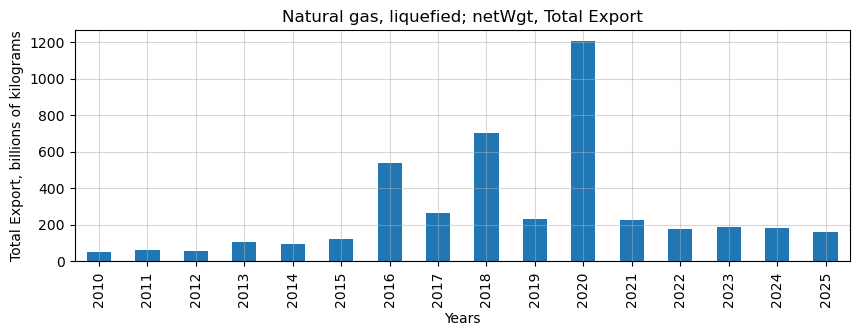

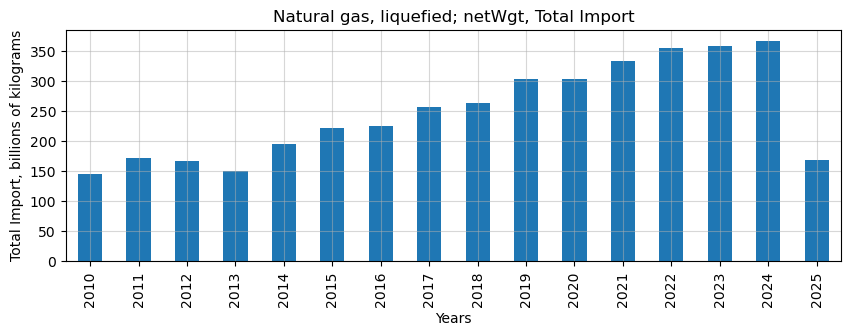

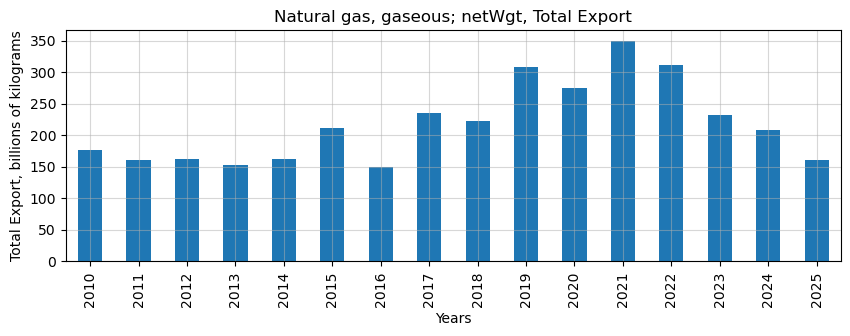

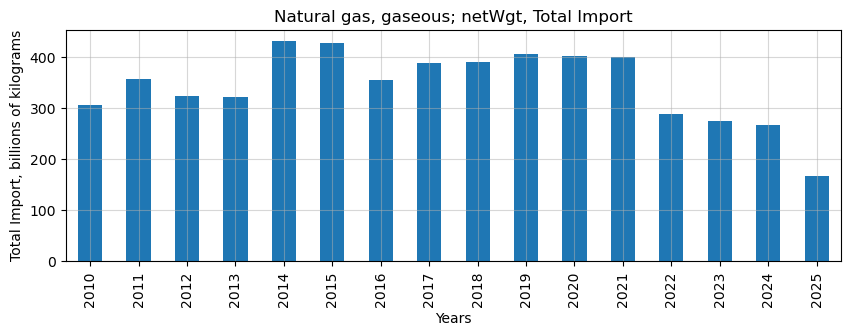

In [15]:
plot_trades(column='netWgt', measure = 'kilograms', df=dfr_kg)

However, there a still problems with values of export of natural liquified gas in 2016, 2018, and 2020.

In [16]:
dfr_kg[((dfr_kg.refYear == 2016) | (dfr_kg.refYear == 2018) | (dfr_kg.refYear == 2020)) 
       & (dfr_kg.flow == 'Export') & (dfr_kg.cmdCode == 271111)].groupby('refYear').netWgt.nlargest(6)

refYear       
2016     27670    2.943000e+11
         29503    1.466527e+10
         31881    1.367999e+10
         31547    1.245401e+10
         31179    1.224867e+10
         30791    1.084984e+10
2018     39210    6.060400e+10
         38226    4.699570e+10
         38709    3.809890e+10
         39180    3.153900e+10
         38224    2.994840e+10
         39184    2.880690e+10
2020     51134    2.863210e+10
         53371    2.608130e+10
         57390    2.422100e+10
         52225    2.310590e+10
         52231    2.276960e+10
         54520    2.203100e+10
Name: netWgt, dtype: float64

In [17]:
bad_rows = dfr_kg[((dfr_kg.refYear == 2016) | (dfr_kg.refYear == 2018) | (dfr_kg.refYear == 2020)) 
       & (dfr_kg.flow == 'Export') & (dfr_kg.cmdCode == 271111)].groupby('refYear').netWgt.nlargest(6).index
bad_indexes = []
for i in range(len(bad_rows)):
    bad_indexes.append(bad_rows[i][1])      #the same to get indexes of these trades

In [20]:
dfr_kg.loc[bad_indexes, needed_cols].sample(7)

,type,period,reporter,flow,partner,cmdCode,primaryValue,qty,qty_type,netWgt,altQty,alt_qty_type
39184,liquefied,2018-03-01,Nigeria,Export,Spain,271111,7.764463e+07,2.880690e+10,kg,2.880690e+10,2.880690e+10,Weight in kilograms
31547,liquefied,2016-10-01,Mozambique,Export,South Africa,271111,1.804589e+07,0.000000e+00,NaN,1.245401e+10,0.000000e+00,Not available or not specified or no quantity.
39210,liquefied,2018-03-01,Nigeria,Export,India,271111,1.475974e+08,6.060400e+10,kg,6.060400e+10,6.060400e+10,Weight in kilograms
52225,liquefied,2020-03-01,Nigeria,Export,India,271111,9.789760e+07,2.310590e+10,kg,2.310590e+10,2.310590e+10,Weight in kilograms
31179,liquefied,2016-09-01,Mozambique,Export,South Africa,271111,1.834781e+07,0.000000e+00,NaN,1.224867e+10,0.000000e+00,Not available or not specified or no quantity.
27670,liquefied,2016-01-01,Myanmar,Export,China,271111,1.489659e+08,2.943000e+11,kg,2.943000e+11,2.943000e+08,Weight in thousand of kilograms
29503,liquefied,2016-05-01,Mozambique,Export,South Africa,271111,2.974434e+07,0.000000e+00,NaN,1.466527e+10,0.000000e+00,Not available or not specified or no quantity.


We again see discrepancies - mostly with Nigeria, but other countries also appear. 
There should not be too huge difference between netWgt (weight in kg) and primaryValue (value in dollars) as price of gas has always been in a range about 0.1$-3$ per kg. Trades with other prices are barely possible: either these are artificial trades or there is a mistake in reports. Let us filter out all trades of unrealistic prices to make a dataset robust for analysis.

I will filter them from the df already without import of Mexico from USA because they confused volume with liters with values in kilograms - it is another type of mistake. These trades are mostly filtered by price but some smaller not, so it is more robust to work without them.

In [24]:
print(f'Original df shape: {dfr.shape}, df without Mexico-Usa trades: {dfr_kg.shape}')
dfr_kg = dfr_kg[dfr_kg.netWgt > 0] #to calculate price and not divide on 0 or have NaN.
print(f'DataFrame with prices shape: {dfr_kg.shape} \
      Lost rows: {dfr.shape[0] - dfr_kg.shape[0]} ({(dfr.shape[0] - dfr_kg.shape[0])*100/dfr.shape[0]:.4f}%)')

Original df shape: (91723, 28), df without Mexico-Usa trades: (91408, 28)
DataFrame with prices shape: (85412, 28)       Lost rows: 6311 (6.8805%)


In [25]:
dfr_kg['kg_price'] = dfr_kg.primaryValue / dfr_kg.netWgt

In [26]:
dfr_kg['kg_price'].describe()

count    8.541200e+04
mean     3.242780e+03
std      2.304733e+05
min      3.237318e-04
25%      3.394225e-01
50%      5.045405e-01
75%      7.759120e-01
max      2.611316e+07
Name: kg_price, dtype: float64

In [27]:
dfr_kg['kg_price'].sample(7)

56238    0.257354
1148     0.387745
72422    0.684273
83845    0.717666
85823    0.849804
25407    0.367051
51368    0.224990
Name: kg_price, dtype: float64

In [28]:
low_lim = dfr_kg.kg_price.quantile(0.01)
high_lim = dfr_kg.kg_price.quantile(0.99)
low_lim, high_lim

(np.float64(0.014883497368046665), np.float64(73.9875654754098))

In [29]:
dfr_kg = dfr_kg[(dfr_kg.kg_price > low_lim) & (dfr_kg.kg_price < high_lim)]

In [30]:
dfr_kg['kg_price'].describe()

count    83702.000000
mean         1.488181
std          5.330534
min          0.014948
25%          0.343402
50%          0.504540
75%          0.763975
max         73.922025
Name: kg_price, dtype: float64

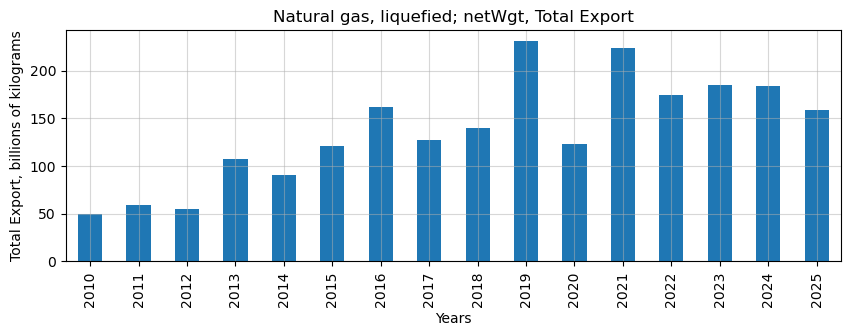

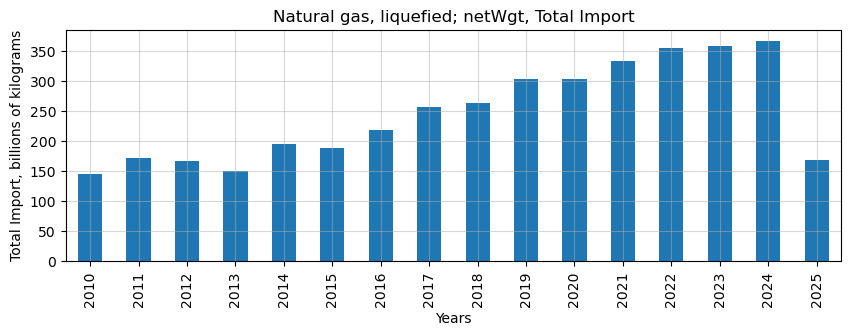

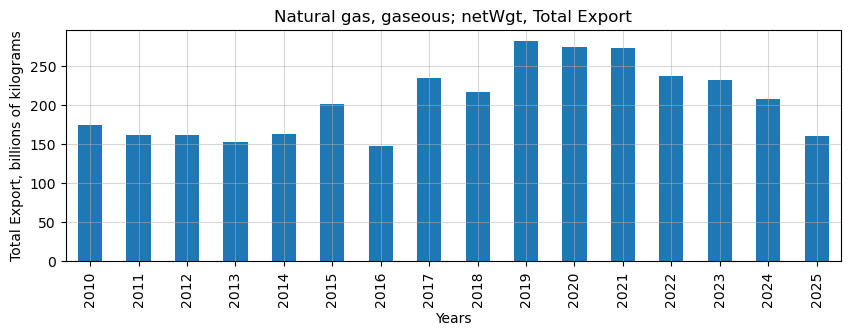

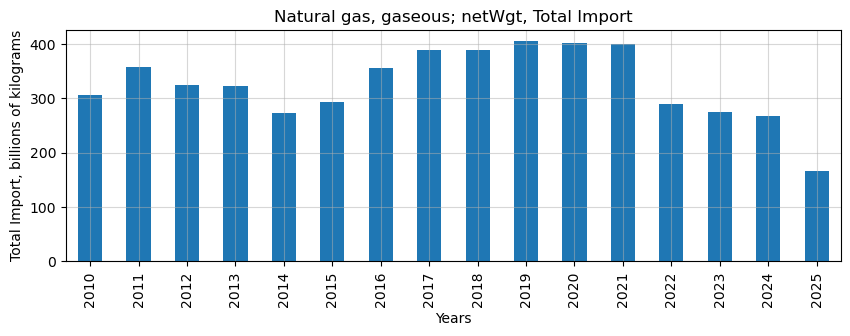

In [31]:
plot_trades(column='netWgt', measure = 'kilograms', df=dfr_kg)

In [32]:

print(f'In total we lost {dfr.shape[0] - dfr_kg.shape[0]} ({(dfr.shape[0] - dfr_kg.shape[0])*100/dfr.shape[0]:.4f}%) rows to have df to work with weights.')

In total we lost 8021 (8.7448%) rows to have df to work with weights.


Now we have df to analyse trade in kilograms to see the evolution of global trade without the influence of prices.
This df is a bit truncated, but it is still robust to compare with the df with dollar values. All huge outliers and mistakes are deleted.

# Part 2: Transport routes and prices analysis.

In [34]:
def get_df_for_kg(df: pd.DataFrame) -> pd.DataFrame:
    """
        The df is now read from main.py .
    """
    dfr_kg = df.copy()
    dfr_kg = dfr_kg[
        ~(
            (dfr_kg["refYear"] >= 2015)
            & (dfr_kg["reporter"] == "Mexico")
            & (dfr_kg["flow"] == "Import")
            & (dfr_kg["partner"] == "United States of America")
        )
    ]
    dfr_kg = dfr_kg[dfr_kg["netWgt"] > 0].copy()
    dfr_kg["kg_price"] = dfr_kg["primaryValue"] / dfr_kg["netWgt"]

    low_lim = dfr_kg["kg_price"].quantile(0.01)
    high_lim = dfr_kg["kg_price"].quantile(0.99)
    dfr_kg = dfr_kg[(dfr_kg["kg_price"] > low_lim) & (dfr_kg["kg_price"] < high_lim)].copy()
    return dfr_kg

In [ ]:
dfr = pd.read_csv("data/processed/comtrade_natural_gas_clean.csv") 

dfr_kg = get_df_for_kg(df=dfr)
dfr.shape, dfr_kg.shape

((91723, 28), (83702, 29))

WARNING: DATA FOR 2025 CAN BE NOT FULL YET!!!

In [36]:
dfs_list = [dfr, dfr_kg]
dfs_cols = {'primaryValue': dfr, 'netWgt': dfr_kg}

print('Grouping trade in dollars and kilograms by transport for each type of gas: \n')
for col, df in dfs_cols.items():
    print(df.groupby(['transport', 'type'])[col].agg('sum').head(8))

Grouping trade in dollars and kilograms by transport for each type of gas: 

transport                 type     
Air                       gaseous      4.147502e+09
                          liquefied    2.488735e+10
Inland waterway           gaseous      1.310085e+08
                          liquefied    6.221765e+07
Land                      gaseous      1.378928e+10
                          liquefied    7.557314e+08
Not elsewhere classified  gaseous      1.262723e+10
                          liquefied    3.217229e+10
Name: primaryValue, dtype: float64
transport                 type     
Air                       gaseous      8.658603e+09
                          liquefied    4.550687e+10
Inland waterway           gaseous      2.361933e+08
                          liquefied    9.269630e+07
Land                      gaseous      3.978005e+10
                          liquefied    3.602702e+08
Not elsewhere classified  gaseous      2.307635e+10
                          liquefied 

In [37]:
def to_billions(df, col):
    """
    Function that divides all values in a given column on 10**9 to represent values in billions
    """
    return df[col] / 10**9
gas_types = list(dfr.type.unique())
gas_types

['gaseous', 'liquefied']

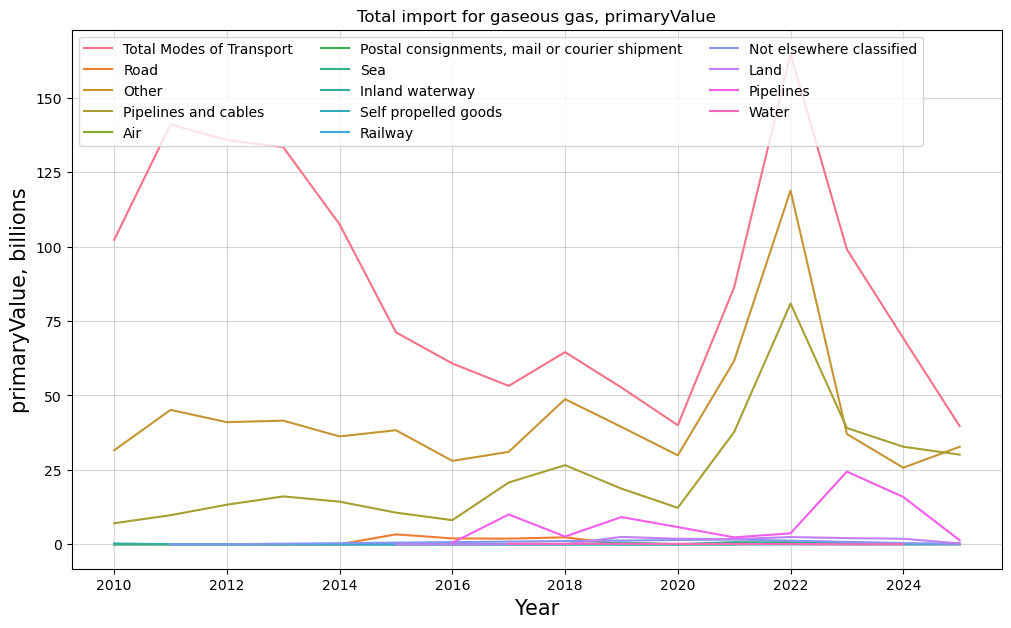

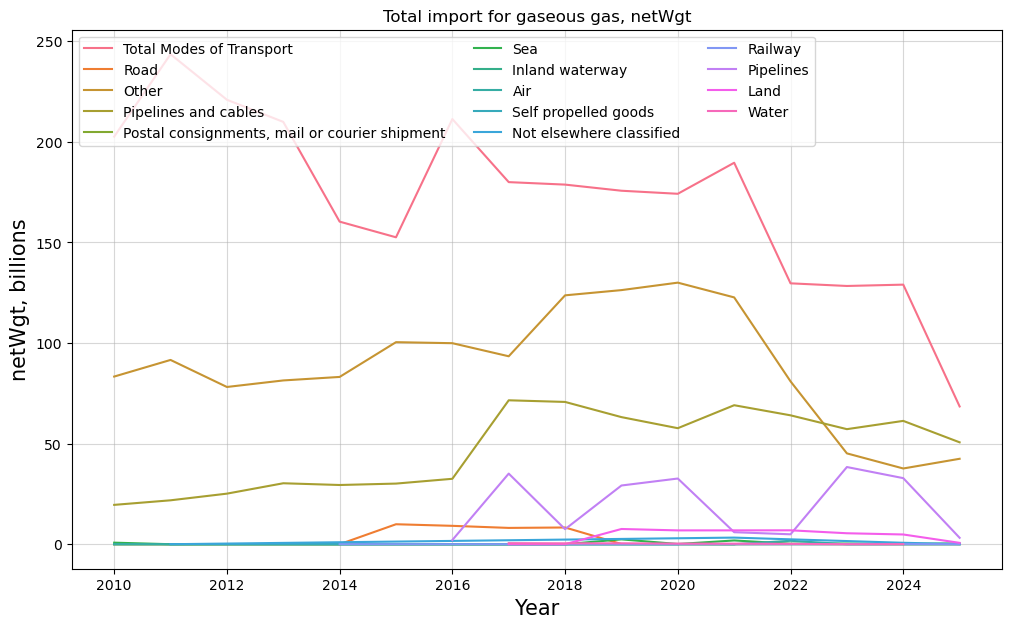

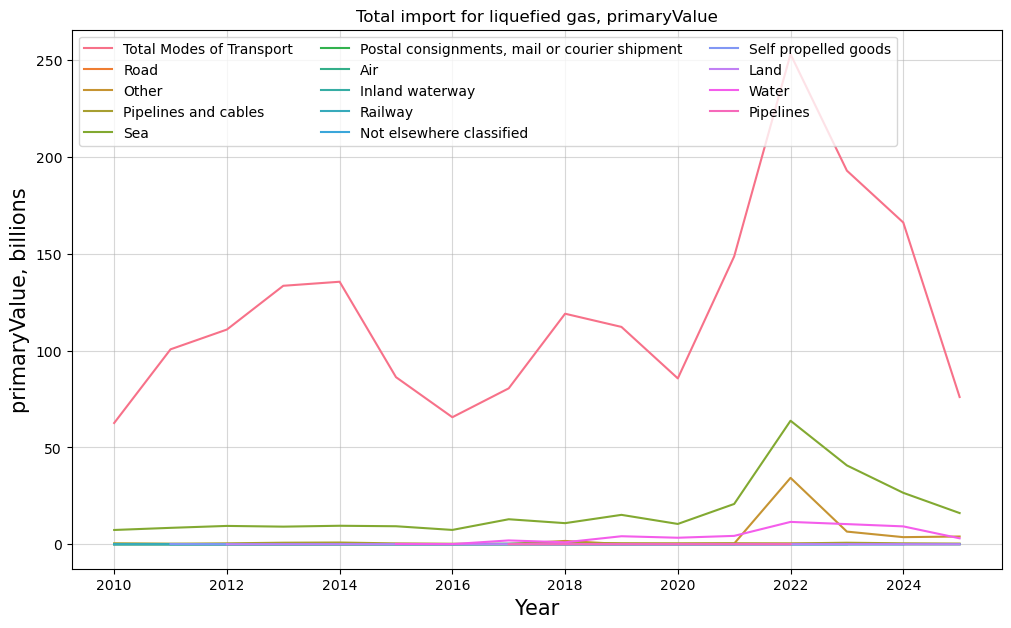

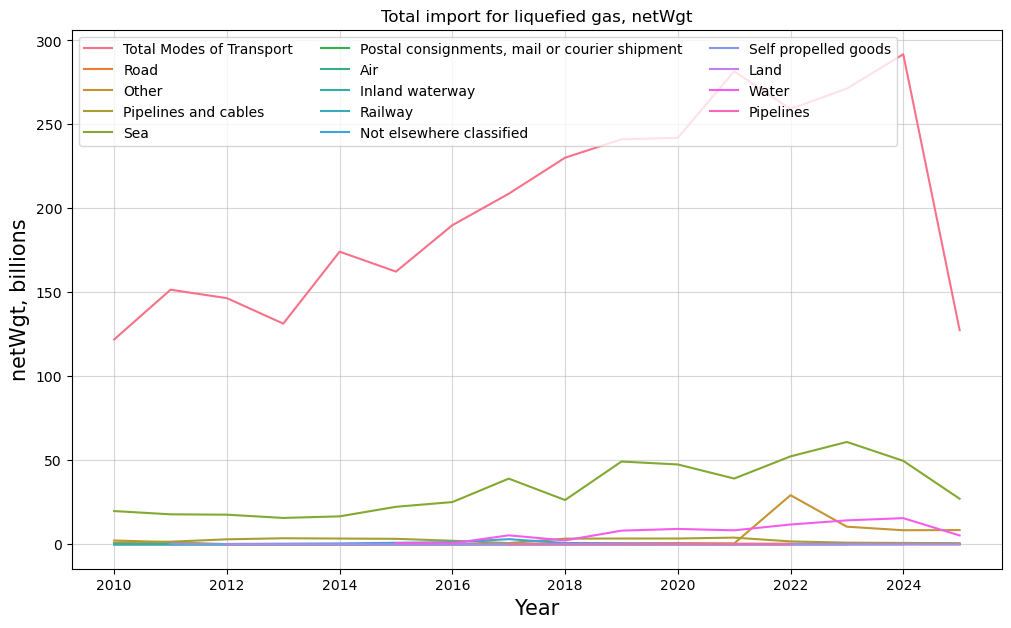

In [38]:
for gas in gas_types:
    for col, df in dfs_cols.items(): #I represent import because it is more reliable than export because better reported (for tariffs calculations)
        plt.figure(figsize=(12,7))
        sns.lineplot(data=df[(df.flow == 'Import') & (df.type == gas)], 
                     y=to_billions(df, col), x = 'refYear', hue='transport', errorbar=None,estimator='sum') # to plot sums, not means by default
        plt.ylabel(str(col) + ', billions',size=15)
        plt.xlabel('Year', size=15)
        plt.legend(ncol=3, loc='upper left')
        plt.title('Total import for ' + str(gas) + ' gas, ' + str(col))
        plt.grid(alpha=0.5)

In [39]:
#top trade routes of import for dollar values

dfr[ (dfr.refYear > 2020) & (dfr.flow == 'Import') & ~ ((dfr.transport == 'Total Modes of Transport') | (dfr.transport == 'Other'))
    ].groupby(['refYear', 'type', 'transport'])['primaryValue'].agg('sum').groupby(['refYear', 'type']).nlargest(2).droplevel([0,1])

refYear  type       transport           
2021     gaseous    Pipelines and cables    3.770781e+10
                    Pipelines               2.308424e+09
         liquefied  Sea                     2.079835e+10
                    Water                   4.308385e+09
2022     gaseous    Pipelines and cables    8.087383e+10
                    Pipelines               3.654780e+09
         liquefied  Sea                     6.379188e+10
                    Water                   1.152821e+10
2023     gaseous    Pipelines and cables    3.903901e+10
                    Pipelines               2.439496e+10
         liquefied  Sea                     4.070491e+10
                    Water                   1.039059e+10
2024     gaseous    Pipelines and cables    3.276140e+10
                    Pipelines               1.588542e+10
         liquefied  Sea                     2.655297e+10
                    Water                   9.216863e+09
2025     gaseous    Pipelines and cables    3.0

In [40]:
#top trade routes of import for kg values

top_transport = dfr_kg[ (dfr_kg.refYear > 2020) & (dfr_kg.flow == 'Import') & ~ ((dfr_kg.transport == 'Total Modes of Transport')
| (dfr_kg.transport == 'Other'))].groupby(['refYear', 'type', 'transport'])['netWgt'].agg('sum')

top_transport = top_transport.groupby(['refYear', 'type']).nlargest(2)
top_transport.droplevel([0,1]).reset_index()

,refYear,type,transport,netWgt
0,2021,gaseous,Pipelines and cables,6.908370e+10
1,2021,gaseous,Land,6.887258e+09
2,2021,liquefied,Sea,3.910382e+10
3,2021,liquefied,Water,8.276041e+09
4,2022,gaseous,Pipelines and cables,6.405887e+10
5,2022,gaseous,Land,6.913792e+09
6,2022,liquefied,Sea,5.231123e+10
7,2022,liquefied,Water,1.174397e+10
8,2023,gaseous,Pipelines and cables,5.718437e+10
9,2023,gaseous,Pipelines,3.835906e+10


Now let us will define top routes by how often did they occur as top routes in each year.
I will also do by sum of all years, but too huge differences in (e.g. in 2022) can artifically give some routes bigger value (it will be just scaled by high prices). In kg df numbers can be altered since it was filtered.

Further you can see a still showed top routes by total trade: they are almost similar to top routes by historical occurrences 
but they differ a bit between kg and dollar values. In contrast, occurences are consistent for both dollars and kg.

So present all top-7 routes by each type fo analysis.

In [41]:
doll_df = dfr.groupby(['type', 'transport']).primaryValue.agg('sum')
doll_df = doll_df.groupby('type').nlargest(7).droplevel(0).reset_index()
doll_df #top routes by total trade in dollars

,type,transport,primaryValue
0,gaseous,Total Modes of Transport,2.628389e+12
1,gaseous,Other,9.244598e+11
2,gaseous,Pipelines and cables,4.425672e+11
3,gaseous,Pipelines,2.211250e+11
4,gaseous,Road,2.696245e+10
5,gaseous,Land,1.378928e+10
6,gaseous,Not elsewhere classified,1.262723e+10
7,liquefied,Total Modes of Transport,2.651707e+12
8,liquefied,Sea,3.871129e+11
9,liquefied,Other,2.591787e+11


In [42]:
kg_df = dfr_kg.groupby(['type', 'transport']).netWgt.agg('sum').groupby('type').nlargest(7).droplevel(0).reset_index()
kg_df #top routes by total trade in kg

,type,transport,netWgt
0,gaseous,Total Modes of Transport,4.918850e+12
1,gaseous,Other,2.022152e+12
2,gaseous,Pipelines and cables,8.392817e+11
3,gaseous,Pipelines,5.472185e+11
4,gaseous,Road,8.012640e+10
5,gaseous,Land,3.978005e+10
6,gaseous,Not elsewhere classified,2.307635e+10
7,liquefied,Total Modes of Transport,4.430839e+12
8,liquefied,Sea,7.543802e+11
9,liquefied,Other,4.207372e+11


In [43]:
top_routes = dfr.groupby(['refYear', 'type', 'transport'])['primaryValue'].agg('sum').groupby(['refYear', 'type']).nlargest(7)

top_routes = top_routes.droplevel([0,1]).reset_index()
top_routes = top_routes.groupby('type').transport.value_counts().groupby('type').nlargest(7).droplevel(0).reset_index()

top_routes # top routes by occurences (for kg df occurrences give the same result)

,type,transport,count
0,gaseous,Other,16
1,gaseous,Pipelines,16
2,gaseous,Pipelines and cables,16
3,gaseous,Total Modes of Transport,16
4,gaseous,Road,14
5,gaseous,Land,9
6,gaseous,Sea,9
7,liquefied,Road,16
8,liquefied,Sea,16
9,liquefied,Total Modes of Transport,16


In [44]:
routes = {'gaseous': list(top_routes[top_routes.type == 'gaseous'].transport.unique()),
          'liquefied': list(top_routes[top_routes.type == 'liquefied'].transport.unique())}
print('Top routes by historical occurrences: \n', routes)

Top routes by historical occurrences: 
 {'gaseous': ['Other', 'Pipelines', 'Pipelines and cables', 'Total Modes of Transport', 'Road', 'Land', 'Sea'], 'liquefied': ['Road', 'Sea', 'Total Modes of Transport', 'Other', 'Pipelines and cables', 'Water', 'Pipelines']}


In [45]:
print('We see that most of the largest trades are either "Total Modes of Transport" or "Other"')
dfr.loc[dfr.primaryValue.nlargest(1000).index, :].transport.value_counts()

We see that most of the largest trades are either "Total Modes of Transport" or "Other"


transport
Total Modes of Transport    616
Other                       303
Pipelines and cables         37
Pipelines                    22
Sea                          12
Not elsewhere classified     10
Name: count, dtype: int64

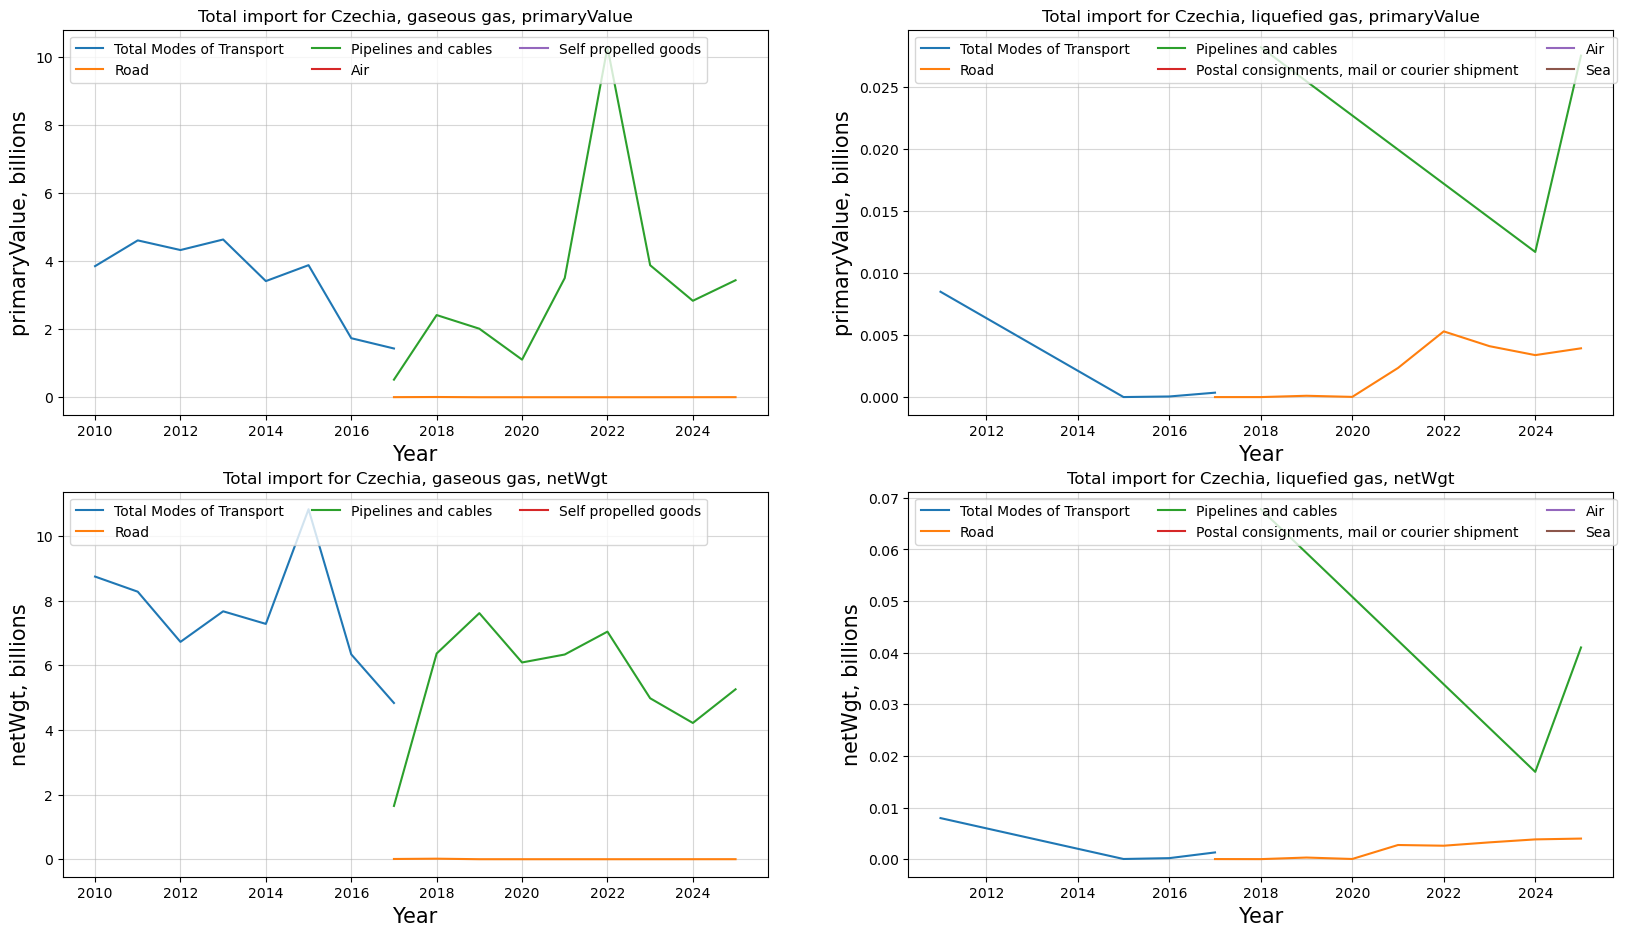

In [46]:
def country_plot(country):
    if country in dfr_kg.reporter.unique():
        plt.figure(figsize=(20,11))
        for i, gas in enumerate(gas_types):
            for col, df in dfs_cols.items():
                plt.subplot(2, 2, i + list((dfs_cols.keys())).index(col)*2 + 1) #to make 4 indexes for each subplot - a bit of math
                sns.lineplot(data=df[(df.reporter == country) & (df.type == gas)], 
                                    y=to_billions(df, col), x = 'refYear', hue='transport', errorbar=None,estimator='sum') # to plot sums, not means by default
                plt.ylabel(str(col) + ', billions',size=15)
                plt.xlabel('Year', size=15)
                plt.legend(ncol=3, loc='upper left')
                plt.title('Total import for ' +country + ', '+ str(gas) + ' gas, ' + str(col) )
                plt.grid(alpha=0.5)
    else:
        print('This is a not a valid name of country in the Harmonised System. Please, type a valid name.')


country_plot('Czechia')

As expected, countries report modes of transport relatively chaotically: especially, the largest countries label almost everything as "Total Modes of Transport". This makes transport and country-wise analysis difficult since space for analysis is not very large.
Further analysis focuses on global trends.

In [47]:
prices = dfr_kg.groupby(['type','flow', 'transport'])[['primaryValue', 'netWgt']].agg('sum').reset_index()
prices['price'] = prices.primaryValue / prices.netWgt
prices = prices[(prices.netWgt > 10**6) & (prices.transport != 'Postal consignments, mail or courier shipment')] #no economic logic, too small values
prices.head()

,type,flow,transport,primaryValue,netWgt,price
0,gaseous,Export,Air,3.256615e+09,6.746106e+09,0.482740
1,gaseous,Export,Inland waterway,1.218786e+08,2.124933e+08,0.573564
2,gaseous,Export,Land,8.201542e+08,5.708508e+08,1.436723
3,gaseous,Export,Not elsewhere classified,1.059977e+10,1.899507e+10,0.558027
4,gaseous,Export,Other,2.312669e+11,6.019839e+11,0.384175


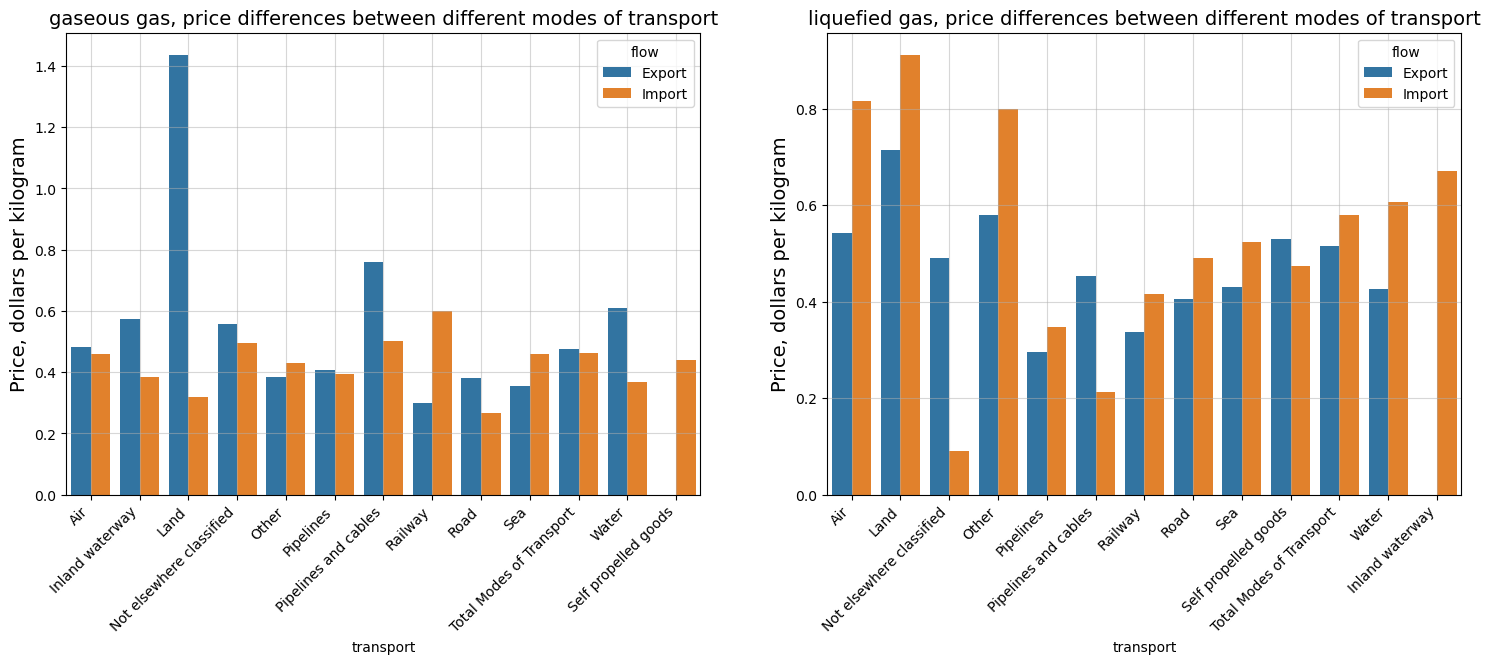

In [48]:
plt.figure(figsize=(18, 6))
for i, gas in enumerate(gas_types):
    plt.subplot(1, 2, i+1)
    sns.barplot(data=prices[prices.type==gas], x='transport', y = 'price', errorbar=None, hue='flow')
    plt.ylabel('Price, dollars per kilogram', size=14)
    plt.title(str(gas) + ' gas, price differences between different modes of transport', size=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.5)  #now graphs are not adjusted to one scale - I will compare them in the later analysis

In [49]:
dfr_kg[(dfr_kg.type == 'gaseous') & (dfr_kg.transport == 'Land') & (dfr_kg.flow == 'Export')].sample(5)

,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,...,isAggregate,reporter,partner,customs_type,transport,qty_type,alt_qty_type,type,flow,kg_price
45613,2019-04-01,2019,4,70,X,499,H5,271121,C03,3000,...,False,Bosnia and Herzegovina,Montenegro,Outright exportation,Land,kg,Weight in kilograms,gaseous,Export,0.735613
89727,2025-06-01,2025,6,70,X,688,H6,271121,C03,3000,...,False,Bosnia and Herzegovina,Serbia,Outright exportation,Land,kg,Weight in kilograms,gaseous,Export,1.113115
83141,2024-06-01,2024,6,70,X,688,H6,271121,C03,3000,...,False,Bosnia and Herzegovina,Serbia,Outright exportation,Land,kg,Weight in kilograms,gaseous,Export,1.040364
87284,2025-01-01,2025,1,70,X,688,H6,271121,C03,3000,...,False,Bosnia and Herzegovina,Serbia,Outright exportation,Land,kg,Weight in kilograms,gaseous,Export,1.007720
88059,2025-02-01,2025,2,604,X,838,H6,271121,C00,3000,...,False,Peru,Free Zones,TOTAL CPC,Land,kg,Volume in cubic meters,gaseous,Export,0.816699


In [50]:
dfr_kg[(dfr_kg.type == 'liquefied') & (dfr_kg.transport == 'Not elsewhere classified') 
       & (dfr_kg.flow == 'Import') & (dfr_kg.reporter == 'South Africa')].sample(5)

,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,...,isAggregate,reporter,partner,customs_type,transport,qty_type,alt_qty_type,type,flow,kg_price
34083,2017-04-01,2017,4,710,M,508,H5,271111,C01,9000,...,False,South Africa,Mozambique,Clearance for home use,Not elsewhere classified,kg,Weight in kilograms,liquefied,Import,0.079097
36003,2017-08-01,2017,8,710,M,508,H5,271111,C01,9000,...,False,South Africa,Mozambique,Clearance for home use,Not elsewhere classified,kg,Weight in kilograms,liquefied,Import,0.084632
34577,2017-05-01,2017,5,710,M,508,H5,271111,C01,9000,...,False,South Africa,Mozambique,Clearance for home use,Not elsewhere classified,kg,Weight in kilograms,liquefied,Import,0.088597
36426,2017-09-01,2017,9,710,M,508,H5,271111,C01,9000,...,False,South Africa,Mozambique,Clearance for home use,Not elsewhere classified,kg,Weight in kilograms,liquefied,Import,0.085260
20170,2014-08-01,2014,8,710,M,508,H4,271111,C01,9000,...,False,South Africa,Mozambique,Clearance for home use,Not elsewhere classified,kg,Weight in kilograms,liquefied,Import,0.157051


Discussion:
We see that prices for gaseous and liquefied types of gas per kg are in one range, but liquefied is more expensive. The gaseous type has one outlier - the high price of export through land. There are 183 rows with moderate export trades through land - they can be results of some emergent needs, and the land route is not the most efficient for gas, which is why the prices are higher than average. 
Liquified gas has too low prices for 'Not elsewhere classified' type, 55 rows. It happened because South Africa imported from Mozambique at very low prices - possibly, the product of some negotiations or counterfeit. 

Price differences between export and import are the premiums taken by merchants and dealers who trade gas internationally. 

In [51]:
prices.head()

,type,flow,transport,primaryValue,netWgt,price
0,gaseous,Export,Air,3.256615e+09,6.746106e+09,0.482740
1,gaseous,Export,Inland waterway,1.218786e+08,2.124933e+08,0.573564
2,gaseous,Export,Land,8.201542e+08,5.708508e+08,1.436723
3,gaseous,Export,Not elsewhere classified,1.059977e+10,1.899507e+10,0.558027
4,gaseous,Export,Other,2.312669e+11,6.019839e+11,0.384175


In [52]:
saldo = prices.pivot(index = ['type', 'transport'],columns='flow', values='price') #pivoting flow to have 2 columns to easily substract
saldo['diff'] = saldo.Export - saldo.Import
saldo.reset_index(inplace=True)
saldo.head()

flow,type,transport,Export,Import,diff
0,gaseous,Air,0.482740,0.457824,0.024916
1,gaseous,Inland waterway,0.573564,0.385231,0.188333
2,gaseous,Land,1.436723,0.320130,1.116593
3,gaseous,Not elsewhere classified,0.558027,0.496769,0.061258
4,gaseous,Other,0.384175,0.429116,-0.044941


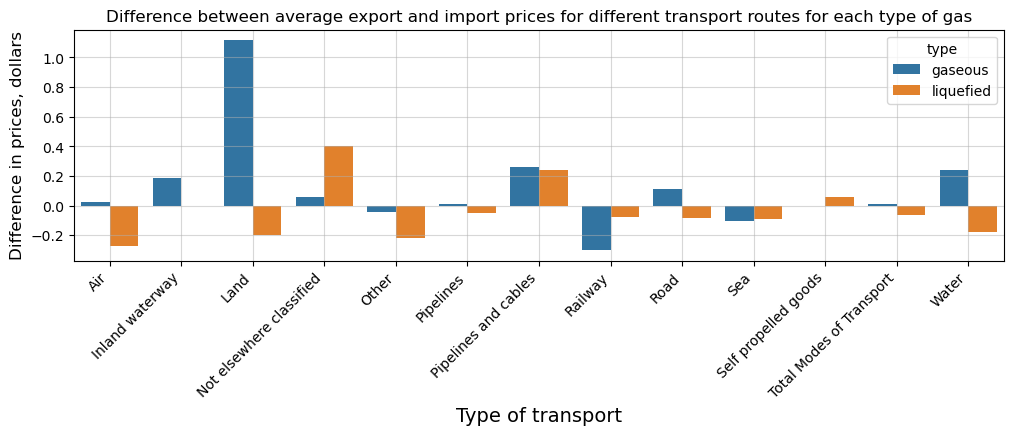

In [53]:
plt.figure(figsize=(12, 3))
sns.barplot(data=saldo, x='transport', y = 'diff', errorbar=None, hue='type')
plt.ylabel('Difference in prices, dollars', size=12)
plt.xlabel('Type of transport', size=14)
plt.title('Difference between average export and import prices for different transport routes for each type of gas', size=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.5)

In [54]:
price_evol = dfr_kg.groupby(['type','refYear'])[['primaryValue', 'netWgt']].sum().reset_index()
price_evol['price'] = price_evol.primaryValue / price_evol.netWgt
price_evol.head()

,type,refYear,primaryValue,netWgt,price
0,gaseous,2010,1.648484e+11,4.805362e+11,0.343051
1,gaseous,2011,2.457164e+11,5.182220e+11,0.474153
2,gaseous,2012,2.492005e+11,4.862061e+11,0.512541
3,gaseous,2013,2.485084e+11,4.740192e+11,0.524258
4,gaseous,2014,1.885922e+11,4.354559e+11,0.433091


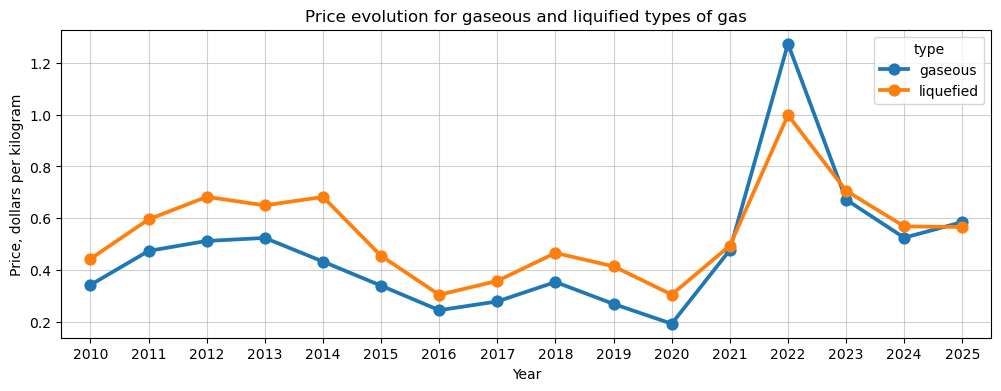

In [55]:
plt.figure(figsize=(12,4))
sns.pointplot(data=price_evol, x='refYear', y='price', hue='type')
plt.title('Price evolution for gaseous and liquified types of gas')
plt.ylabel('Price, dollars per kilogram')
plt.xlabel('Year')
plt.grid(alpha=0.6)

Primarily, liquefied gas is more expensive per kilogram than gaseous because of the costs of liquefaction and shipping.
An interesting situation happened in 2022: the gaseous type became more expensive for a period of time. The resulting value for the year is smoothed; the peak difference was much larger. That happened because of the global energy crisis, which started in 2021 (https://en.wikipedia.org/wiki/Global_energy_crisis_(2021%E2%80%932023)) and the Russian invasion of Ukraine, which started in 2022.
Currently, the situation seems to have stabilised with still higher prices than the median.

In [56]:
route_prices = dfr_kg.groupby(['type','refYear', 'transport'])[['primaryValue', 'netWgt']].agg('sum').reset_index()
route_prices['price'] = route_prices.primaryValue / route_prices.netWgt
print(route_prices.shape)
route_prices = route_prices[(route_prices.netWgt > 10**8)] #to represent only the most reliable values and avoid overlapping
route_prices.shape

(330, 6)


(204, 6)

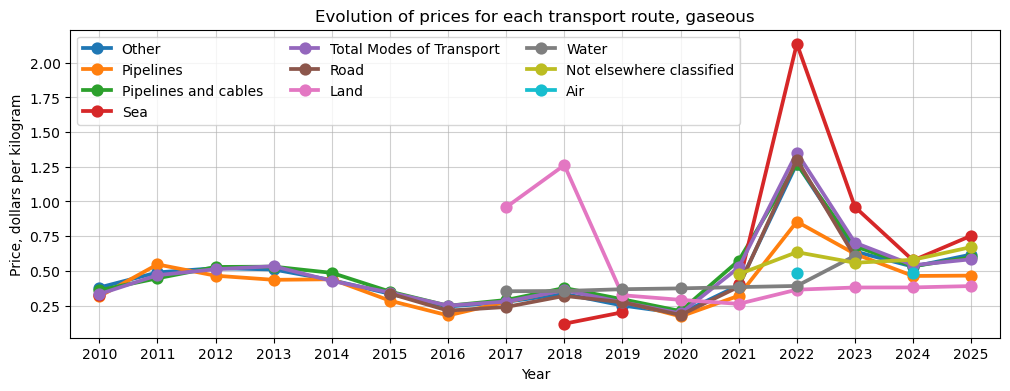

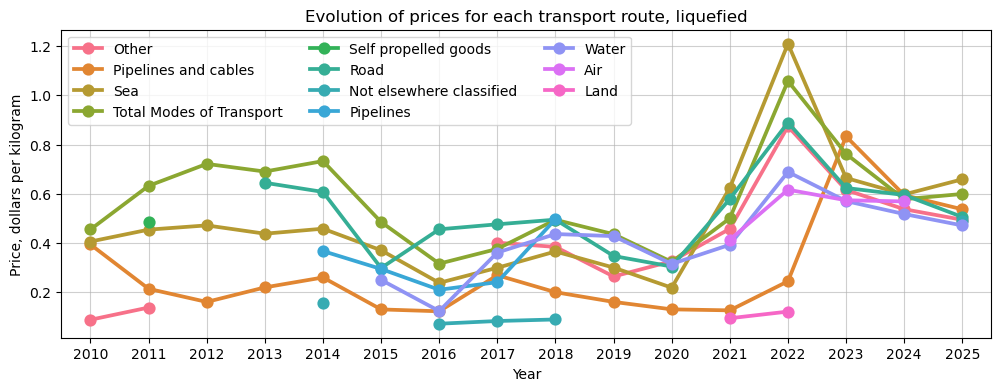

In [57]:
for gas_type in gas_types:
    plt.figure(figsize=(12,4))
    sns.pointplot(data=route_prices[route_prices.type==gas_type], x='refYear', y='price', hue='transport')
    plt.title('Evolution of prices for each transport route, ' +str(gas_type))
    plt.ylabel('Price, dollars per kilogram')
    plt.xlabel('Year')
    plt.legend(ncol=3)
    plt.grid(alpha=0.6)

Summarising results:
This analysis was devoted to transport routes and price differences. More insights will be understandable with other parts of the analysis; however, some things can be stressed at this point:

1. Most of the trades are classified as "Total Modes of Transport" or "Other" - major countries do not want to give information about their trade of such a strategic resource as natural gas. For the gaseous type, the top route is Pipelines. Other important routes are (unexpectedly) Road and Land with Sea. Liquefied type is primarily traded by Sea and Water (which is the same); other major transport modes are Pipelines and (again, unexpectedly) even Air.

2. Pipelines (and cables), railway, road, and water/sea from all defined (not "total" or "other") modes show the lowest average prices across history for both types of gas (except for "Pipelines and Cables" for gaseous). Land and air are usually the most expensive routes - usually traded not regularly, in moderate amounts, which can tell about the emergence of these trades. 

3. Prices of liquefied gas are higher; however, the crisis in 2022 is vividly visible - the gaseous type became scarce, and Sea trade prices skyrocketed. Historically, price range between different routes was smaller for gaseous type than for liquefied, where sea transport was twice as expensive as pipelines; however, in 2022 range of prices for different transport modes widened frighteningly. For now, the situation seems to have stabilised. The 2022 crisis needs attention in subsequent analysis.

# Part 3: network analysis

In [58]:
print("How many n/a values we have in columns of each df:")
dfs_list = [dfr, dfr_kg]

for df in dfs_list:
    print("-"*50, f"\n ")
    for i in df.columns:
        if df[i].isna().sum():
            print(f"column {i} has {df[i].isna().sum()} n/a columns ({df[i].isna().sum()*100/df.shape[0]}%).")

How many n/a values we have in columns of each df:
-------------------------------------------------- 
 
column qty has 3466 n/a columns (3.778768683972395%).
column altQty has 3466 n/a columns (3.778768683972395%).
column netWgt has 1433 n/a columns (1.5623126151565039%).
column qty_type has 21133 n/a columns (23.04002267697306%).
-------------------------------------------------- 
 
column qty has 2507 n/a columns (2.995149458794294%).
column altQty has 2507 n/a columns (2.995149458794294%).
column qty_type has 15326 n/a columns (18.310195694248645%).


Now it is needed to prepare data in each df to build weighted directed graph.

In [59]:
print(dfr.shape, dfr_kg.shape, dfr.shape[0] -  dfr_kg.shape[0])
diff = [index for index in dfr.index if index not in dfr_kg.index] #what indexes we lost in dfr_kg
print(len(diff))
print(f"For analysis in kg we lost {dfr.loc[diff, :].primaryValue.sum()/10**9:.4f} billions of dollars \
       ({dfr.loc[diff, :].primaryValue.sum()*100/ dfr.primaryValue.sum():.4f}% of dataset)")

(91723, 28) (83702, 29) 8021
8021
For analysis in kg we lost 592.5715 billions of dollars        (7.5847% of dataset)


In [60]:
dfr.columns

Index(['period', 'refYear', 'refMonth', 'reporterCode', 'flowCode',
       'partnerCode', 'classificationCode', 'cmdCode', 'customsCode',
       'motCode', 'qtyUnitCode', 'qty', 'isQtyEstimated', 'altQtyUnitCode',
       'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated',
       'primaryValue', 'isAggregate', 'reporter', 'partner', 'customs_type',
       'transport', 'qty_type', 'alt_qty_type', 'type', 'flow'],
      dtype='object')

In [61]:
#Preparing data for directed graph
for df in dfs_list:
    df["source"] = np.where(df.flow == "Export", df.reporter, df.partner) 
    # if export - source is reporter (reporter exports to partner), if import - source is partner (partner exports to reporter)
    df["target"] = np.where(df.flow == "Export", df.partner, df.reporter) # similar reversed logic for target

In [62]:
# creating graphs for each year from our dfs with 2 types of weight of edges: trade in dollars and trade in kilograms. 

dfs_cols = {"primaryValue": dfr, "netWgt": dfr_kg}
dfs_list=[dfr, dfr_kg]
gas_types = list(dfr.type.unique())
graphs = {gas: {"primaryValue": {}, "netWgt": {}} for gas in gas_types}
weights = copy.deepcopy(graphs)

for gas_type in gas_types:
    for col, df in dfs_cols.items():
        for year in year_list:
            dfg = df[df.type == gas_type]
            dfgy = dfg[dfg.refYear == year]

            G = nx.from_pandas_edgelist(df = dfgy, source = "source", 
                                    target = "target", edge_attr=True, create_using=nx.DiGraph)

            edges = G.edges()
            weight = np.array([G[u][v][col] for u, v in edges])

            
            graphs[gas_type][col][f"G_{year}"] = G
            weights[gas_type][col][f"G_{year}"] = weight

In [63]:
graphs

{'gaseous': {'primaryValue': {'G_2010': <networkx.classes.digraph.DiGraph at 0x1686e0910>,
   'G_2011': <networkx.classes.digraph.DiGraph at 0x16859c7d0>,
   'G_2012': <networkx.classes.digraph.DiGraph at 0x16872fe90>,
   'G_2013': <networkx.classes.digraph.DiGraph at 0x16875a450>,
   'G_2014': <networkx.classes.digraph.DiGraph at 0x1687473d0>,
   'G_2015': <networkx.classes.digraph.DiGraph at 0x1686eb3d0>,
   'G_2016': <networkx.classes.digraph.DiGraph at 0x168765a10>,
   'G_2017': <networkx.classes.digraph.DiGraph at 0x1686eb750>,
   'G_2018': <networkx.classes.digraph.DiGraph at 0x1687cdf90>,
   'G_2019': <networkx.classes.digraph.DiGraph at 0x168776390>,
   'G_2020': <networkx.classes.digraph.DiGraph at 0x1687b3b50>,
   'G_2021': <networkx.classes.digraph.DiGraph at 0x1685a8050>,
   'G_2022': <networkx.classes.digraph.DiGraph at 0x1687649d0>,
   'G_2023': <networkx.classes.digraph.DiGraph at 0x168b7afd0>,
   'G_2024': <networkx.classes.digraph.DiGraph at 0x168b6e610>,
   'G_2025': 

In [64]:
#parameters to make nice graph

def get_layout(G:nx.DiGraph):
    "Function to create nice layout for a given graph"
    
    return nx.spring_layout(G, k=1.4, scale=2)

def get_sizes(G:nx.DiGraph, col: str, scale=100):

    "Function to adjust size of nodes to their weighted degree"

    weighted_degrees = dict(G.degree(weight=col))
    degrees = np.array(list(weighted_degrees.values()))
    sizes = np.sqrt(degrees)/scale
    return sizes

def get_width(G:nx.DiGraph, weight, scale=10000):
    "Function to adjust size of nodes to their weighted degree"

    return np.sqrt(weight)/scale

def get_color(G: nx.DiGraph, weight):

    "Function that colors importers in green and exporters in red"

    import_weights = {}
    export_weights = {}

    for node in G.nodes():
        import_weights[node] = sum(d[weight] for u, v, d in G.in_edges(node, data=True))
        export_weights[node] = sum(d[weight] for u, v, d in G.out_edges(node, data=True))

    colors = []
    for node in G:
        if import_weights[node] > export_weights[node]:
            colors.append("green")  
        else:
            colors.append("red") 

    return colors


def draw_graph(type: str, measure: str, year: int):

    "Function that draws final graw with all settings given by previous functions"
    
    G = graphs[type][measure][f"G_{year}"]
    weight = weights[type][measure][f"G_{year}"]
    
    plt.figure(figsize=(10,7))
    nx.draw(G, get_layout(G), node_size=get_sizes(G, measure), width=get_width(G, weight=weight), 
        edge_color="grey",  node_color=get_color(G, measure), with_labels=True, font_size=8)


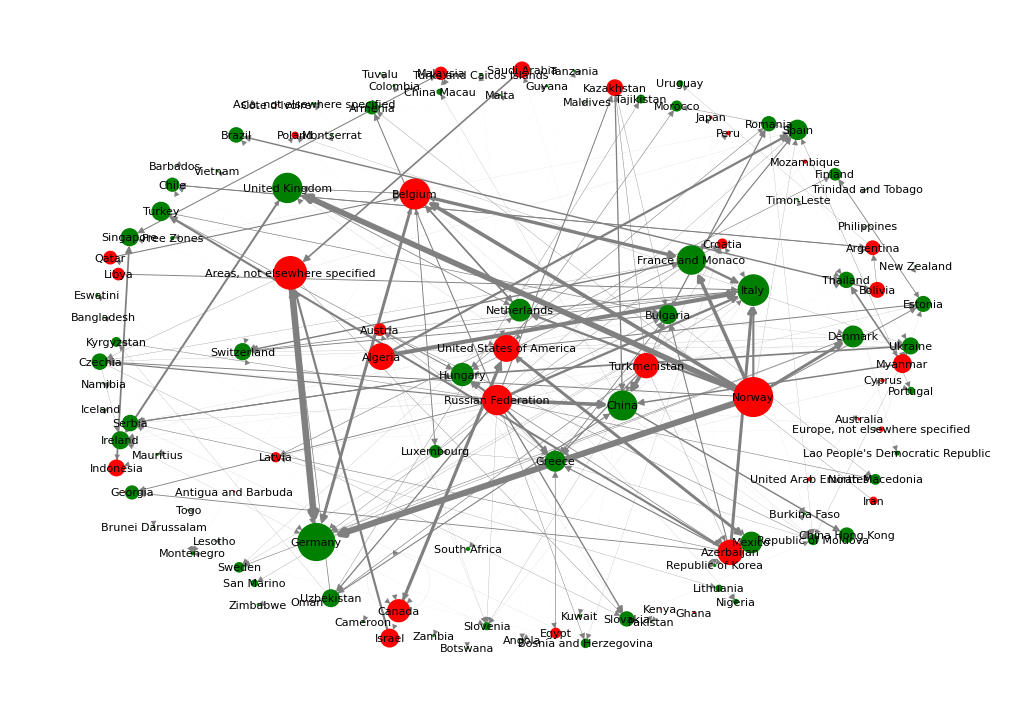

In [65]:
draw_graph("gaseous", "primaryValue", 2024)

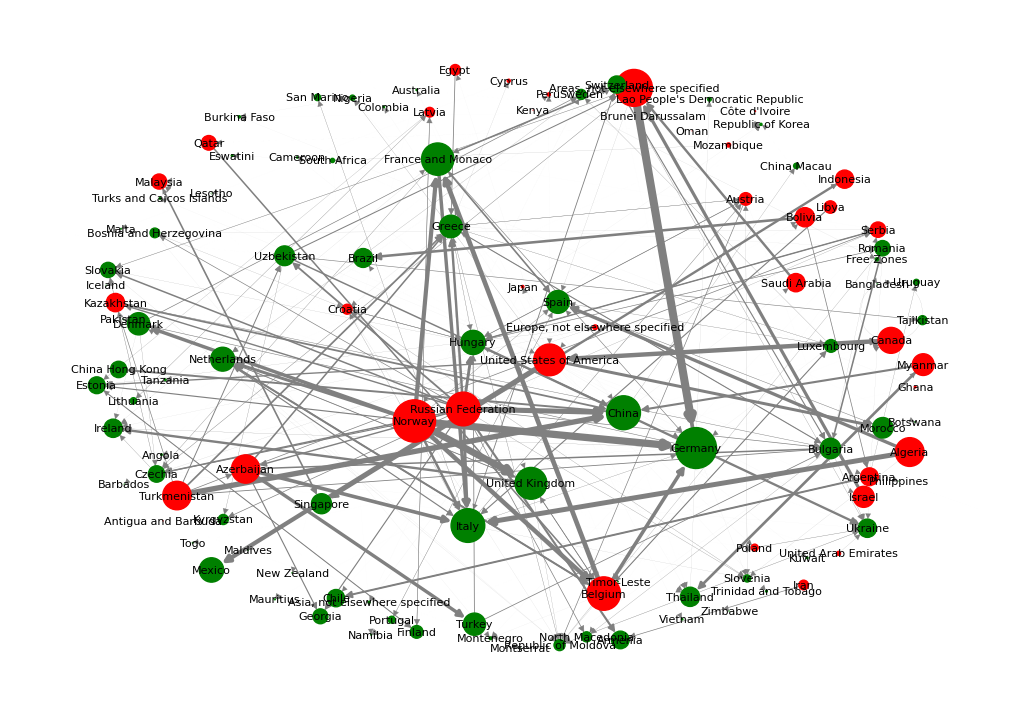

In [66]:
draw_graph("gaseous", "netWgt", 2024)

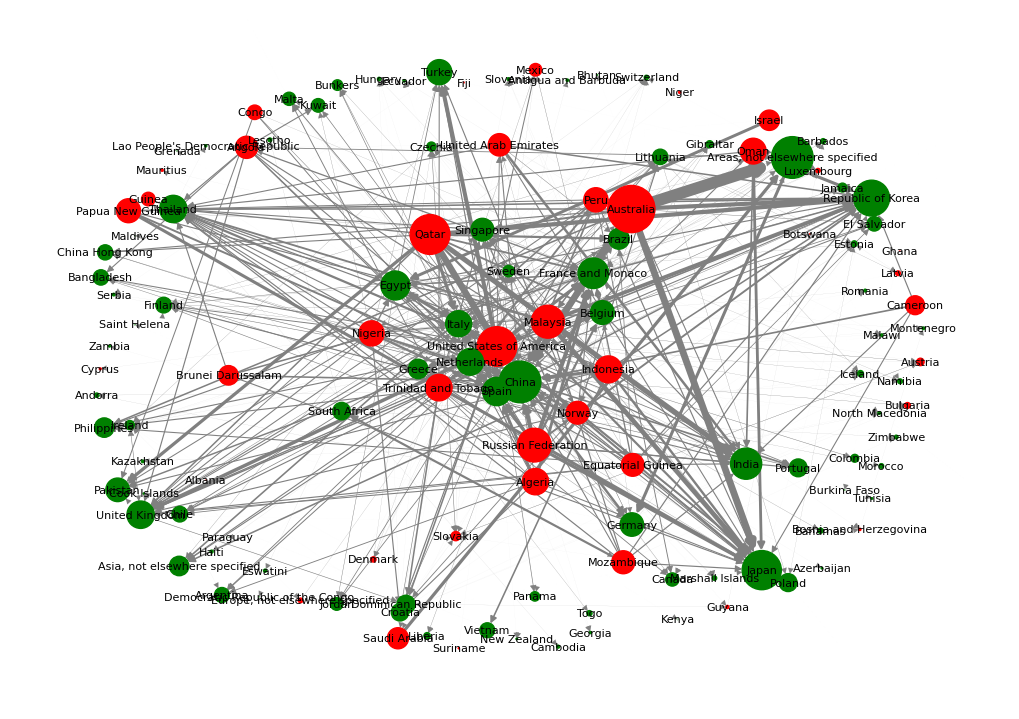

In [67]:
draw_graph("liquefied", "netWgt", 2024)

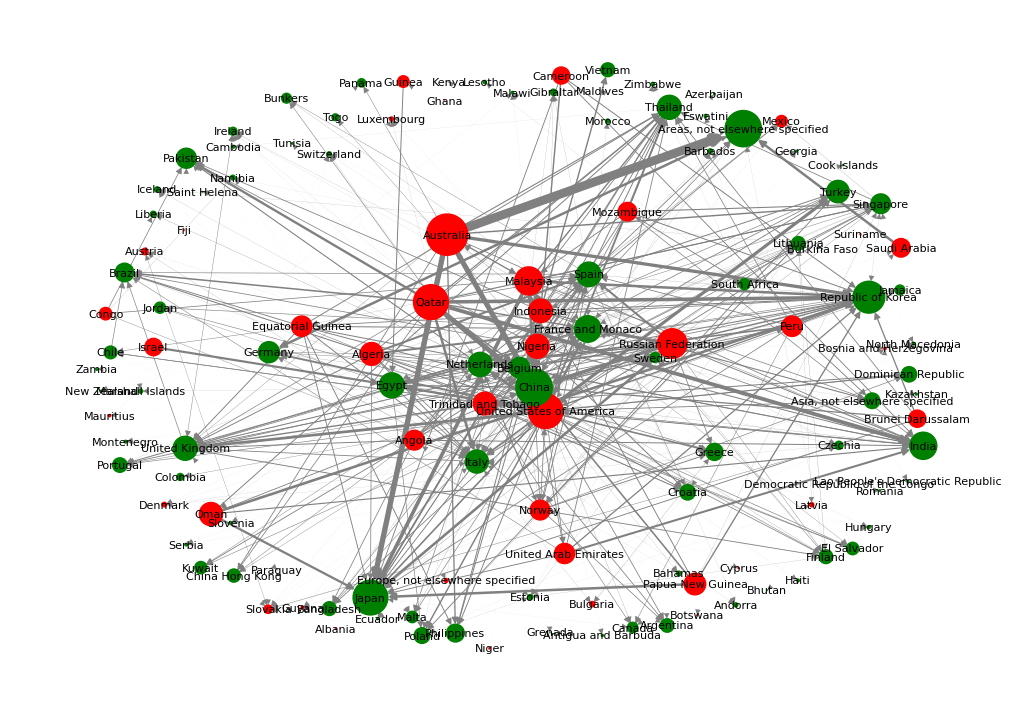

In [68]:
draw_graph("liquefied", "primaryValue", 2024)

In [69]:
def global_efficiency(G: nx.DiGraph, weight: str):

    """
    Function that returns the efficiency of the graph. It appeared that the efficiency metric in networkx is pretty limited and does not
    work with directed and weighted graphs. This metric, based on the same principle, adjusts for weight.
    Inputs: graph, its weight attribute.
    Output: efficiency of the graph.
    Note: for the inverted graph, it was required to invert weights as more trade is better, not worse, as the shortest path treats it.
    """

    num_nodes = G.number_of_nodes()
    all_pairs = num_nodes*(num_nodes-1)
    efficiency_sum = 0

    for source, targets in nx.shortest_path_length(G, weight=weight):
        for target, distance in targets.items():

            if source != target:
                if distance > 0:
                    efficiency_sum += 1 / distance

    return efficiency_sum/all_pairs

In [70]:
def global_efficiency_log_normalized(G: nx.DiGraph, weight: str):

    """
    Global_efficiency above gives extremely small values, which appeared because 
    1. the shortest path is inverted, not the weights, and 2. the distribution of weights in natgas is catastrophically heavy-tailed:
    plenty of small trades with a few enormous. This function fixes the first effects and smoothes the second.
    """

    G_cost = G.copy()
    
    max_weight = max(d[weight] for u, v, d in G.edges(data=True))
    log_max = np.log2(max_weight + 1) # +1 if the trade is 0

    for u, v, data in G_cost.edges(data=True):
        trade_vol = data.get(weight, 0)
        
        if trade_vol > 0:
            log_weight = np.log2(trade_vol + 1)
            data["cost"] = log_max / log_weight
        else:
            G_cost.remove_edge(u, v)

    #Now the same as in the efficiency before
    num_nodes = G_cost.number_of_nodes()
    
    all_pairs = num_nodes * (num_nodes - 1)
    efficiency_sum = 0

    for source, targets in nx.shortest_path_length(G_cost, weight="cost"):
        for target, distance in targets.items():
            if source != target:
                efficiency_sum += 1 / distance

    return efficiency_sum / all_pairs

In [71]:
def get_metrics(func:nx.function, weights:bool) -> pd.DataFrame:

    """
    This function calculates some metrics of the graph based on the given function to store it in comfortable df.
    Input: function; whether it takes weight.
    Output: DataFrame 
    """

    df = [] #list is more memory efficient than doing using pd.concat()
    for gas_type in gas_types:
        for col in list(dfs_cols.keys()):
            for year in year_list:

                G = graphs[gas_type][col][f"G_{year}"]

                if weights:
                    weight = func(G, weight=col)
                else:
                    weight = func(G)
                
                df.append({"type": gas_type, 
                           "measure": col, 
                           "year": year, 
                           "function": str(func.__name__),
                           "value": weight})
    
    return(pd.DataFrame(df))



get_metrics(func = nx.average_clustering, weights=True).head()

,type,measure,year,function,value
0,gaseous,primaryValue,2010,average_clustering,0.000574
1,gaseous,primaryValue,2011,average_clustering,0.000533
2,gaseous,primaryValue,2012,average_clustering,0.000757
3,gaseous,primaryValue,2013,average_clustering,0.000897
4,gaseous,primaryValue,2014,average_clustering,0.000520


In [72]:
functions_list = {nx.average_clustering: True, nx.degree_assortativity_coefficient: True,
                  nx.reciprocity: False, nx.density: False, global_efficiency: True, global_efficiency_log_normalized: True}

dfs_list = []
for function, weight in functions_list.items():
    dfs_list.append(get_metrics(func = function, weights=weight))


df_metrics = pd.concat(dfs_list, ignore_index=True)
df_metrics = df_metrics.pivot(columns="function", index=["type", "measure", "year"], values="value").reset_index()
df_metrics.tail()

function,type,measure,year,average_clustering,degree_assortativity_coefficient,density,global_efficiency,global_efficiency_log_normalized,reciprocity
59,liquefied,primaryValue,2021,0.000531,0.083982,0.033217,0.000110,0.099396,0.219595
60,liquefied,primaryValue,2022,0.000577,0.147750,0.035784,0.000111,0.102065,0.219178
61,liquefied,primaryValue,2023,0.000529,0.136632,0.037290,0.000195,0.108718,0.212766
62,liquefied,primaryValue,2024,0.000584,0.079327,0.038140,0.000265,0.112273,0.248387
63,liquefied,primaryValue,2025,0.000608,0.003583,0.030323,0.001403,0.096228,0.208511


In [73]:
df_metrics["type_measure"] = df_metrics["type"] + ", " + df_metrics["measure"]  #to compare everything on one graph
df_metrics.head() 

function,type,measure,year,average_clustering,degree_assortativity_coefficient,density,global_efficiency,global_efficiency_log_normalized,reciprocity,type_measure
0,gaseous,netWgt,2010,0.000643,0.108761,0.019139,0.000246,0.032173,0.363636,"gaseous, netWgt"
1,gaseous,netWgt,2011,0.000750,0.130950,0.020485,0.000765,0.041399,0.324561,"gaseous, netWgt"
2,gaseous,netWgt,2012,0.001027,0.238546,0.017414,0.000413,0.032127,0.234146,"gaseous, netWgt"
3,gaseous,netWgt,2013,0.000687,0.200689,0.018726,0.000597,0.040007,0.320675,"gaseous, netWgt"
4,gaseous,netWgt,2014,0.000561,0.209241,0.018243,0.000397,0.036624,0.314894,"gaseous, netWgt"


In [74]:
def plot_metric(metric: str, df = df_metrics):
    "This function creates a lineplot for a given metric with 4 hues based on the type of gas and measurement"
    plt.figure(figsize=(12,6))

    sns.pointplot(data = df, 
                x="year", y=metric, errorbar = None, hue="type_measure")
    plt.ylabel("Value", size=12)
    plt.xlabel("Year", size=12)
    plt.grid(True)
    plt.title("Evolution of " + metric + " for all years")

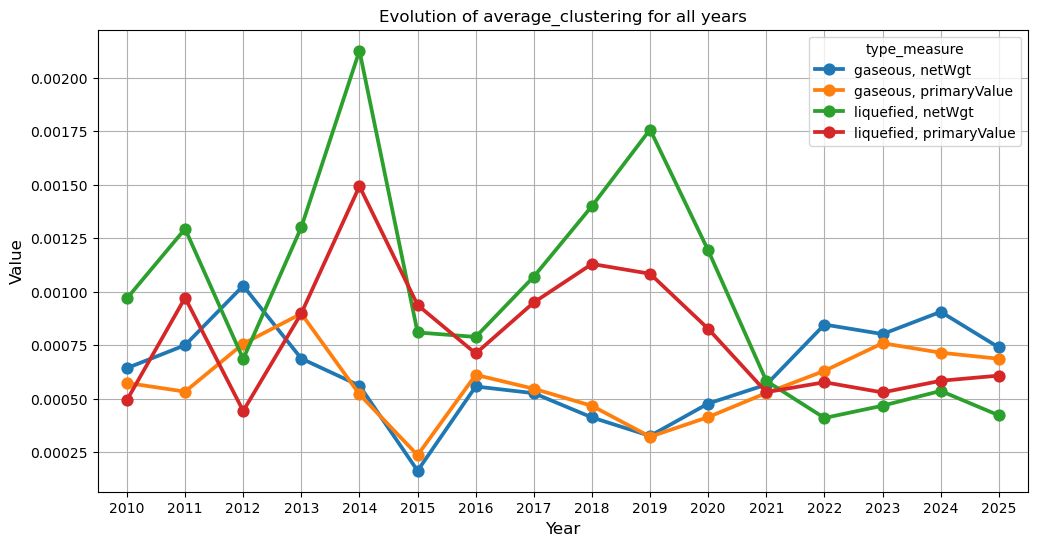

In [75]:
plot_metric("average_clustering")

Explanations:
A clustering coefficient is a measure of the degree to which nodes in a graph tend to cluster together. A cluster is a group of 3 nodes (a triangle). The higher clustering, the higher chance that if country A trades with countries B and C, countries B and C trade with each other. So, trades are not simply for end-use, but the flow is high among different countries, with higher interconnectedness.
We see that gas has a very low weighted clustering coefficient - there are no huge hubs, gas is just bought directly by the importer from the exporter, and then consumed. 

Throughout history, liquified gas has shown higher clustering - it has been traded more internationally compared to direct pipes from producers to consumers of gaseous natural gas. However, in 2020-2021, the clustering coefficient for liquified type went down abruptly and is now even lower than for gaseous type without noticeable tendency to return. It indicates the "narrowing" of the market - the globalization of trade reduced.


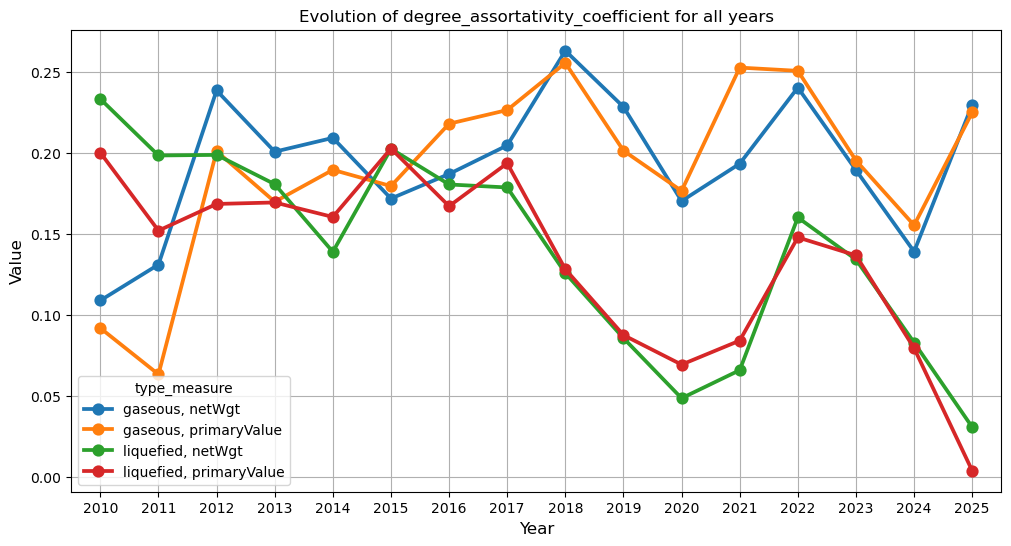

In [76]:
plot_metric("degree_assortativity_coefficient")

Degree assortativity coefficient measures the rate of assortativity in the network: higher coefficient (up to +1) means that big countries (by total trade) trade primarily with big ones and small countries trade with small ones; lower coefficient (up to -1) means that big countries trade more with small countries (core-periphery/star structure: a lot of small countries connected to chief one). Close to 0 values indicate that there are no such tendencies: random distribution of trades.

Gaseous type demonstrates moderate positive values: inter-country pipes facilitate the flow of large amounts directly to the consumer, which is beneficial for both sides. It aligns with the result received above. Still, values are not critical and do not demonstrate a direct trend toward deglobalization.

Liquefied gas has shown 2 jumps in the direction of random distribution; however, the data for 2025 is not complete yet to be sure in these values. This type of gas does not demonstrate a high degree of direct consumer-supplier relationships. However, values are not negative to indicate the establishment of important hubs (which would be good for international trade). Additionally, time series for liquified gas are relatively volatile - the international market is young for liquified type of gas, and it remains to be seen what tendencies will establish in the future.

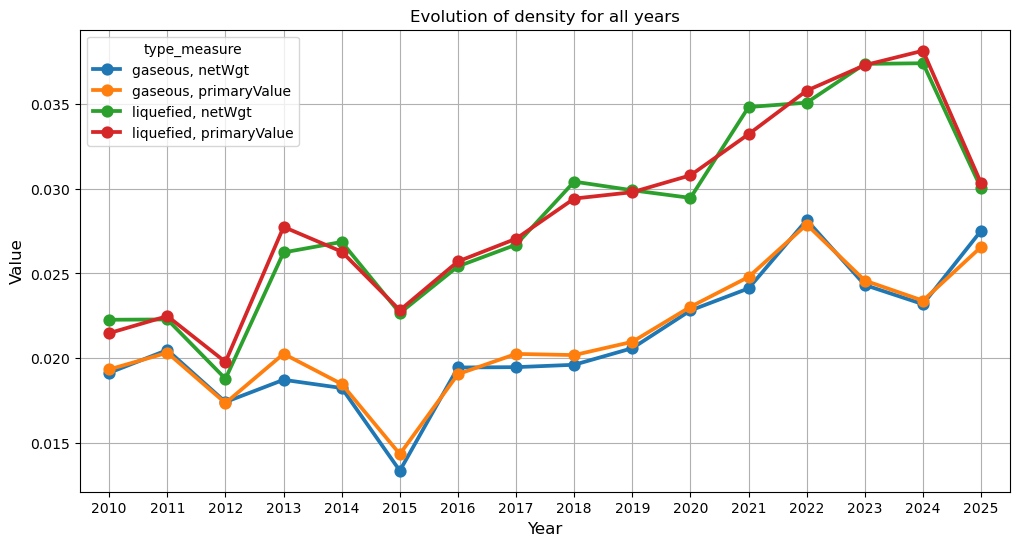

In [77]:
plot_metric("density") #Note - density does not accept weights.

Density is calculated as (Number of existing edges in the network)/(Number of possible edges in the network). So, it is an answer to a question: "Of all the possible trade connections that could exist between countries ( N*(N-1) for directed graph, where N is number of nodes), how many actually do exist?" Rising density indicates about growing number of connections between countries. Remember: density is unweighted!!!

Liquified gas permanently shows higher density, which is expected due to the reasons mentioned above. In recent years, we have seen a growing density for both types of gas, which could indicate growing globalization. However, we must remember that this metric is unweighted: although new routes are established, they are not necessarily meaningful. The weighted metrics above do not show the trend toward higher interconnectedness. So, despite the network"s topology is improving, we cannot say the same about the weighted graph.

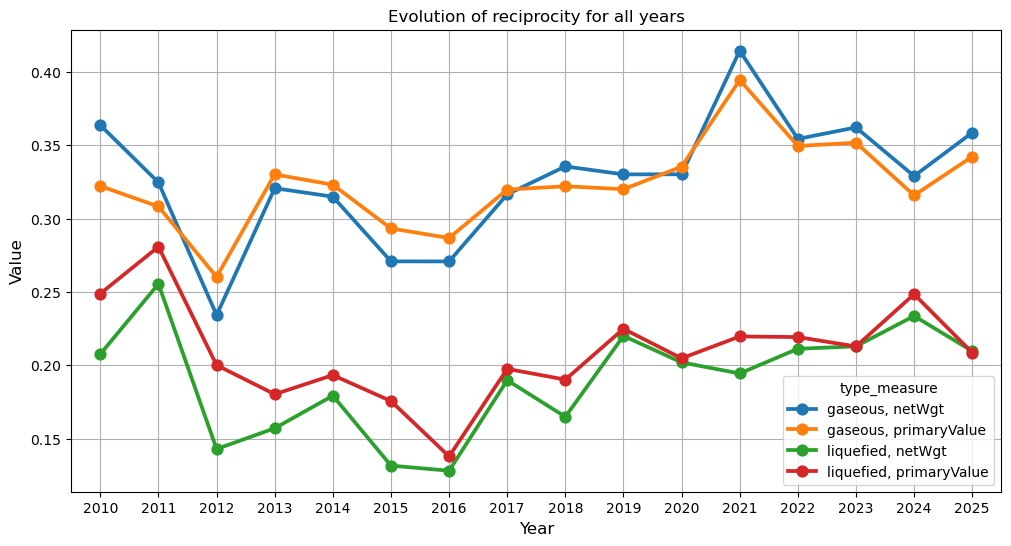

In [78]:
plot_metric("reciprocity") #Note - reciprocity does not accept weights.

Reciprocity = (Number of reciprocal edges)/(Total number of edges). So, it is a percentage of mutual trades in the network. Surprisingly, it is not close to 0 for both types, and even higher for the gaseous type than for the liquified one. 
Often, countries can send each other gas they saved in storage - we see it is popular for the gaseous type. I believe most of the mutual trades occurred in the EU (you can watch the network at the start of the file). However, it is, as density, an unweighted metric - the existence of an edge does not imply its importance.

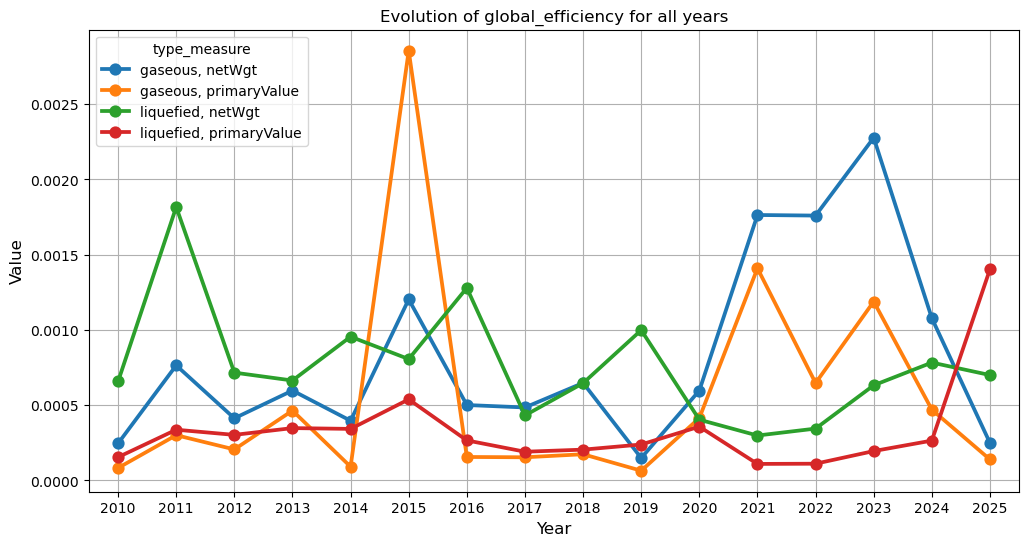

In [79]:
plot_metric("global_efficiency")

Values are minimal, but we know the formula is correct: we need to consider only the evolution of values.
Higher efficiency means better sharing of information in the network - in terms of trade, it means countries can reach each other more easily, trade is internationalized. Unfortunately, we do not see this for both types of gas: sometimes spikes can be noticed; however, they are temporary and likely a product of structural changes of big players" trades, not of better conditions of trade. 

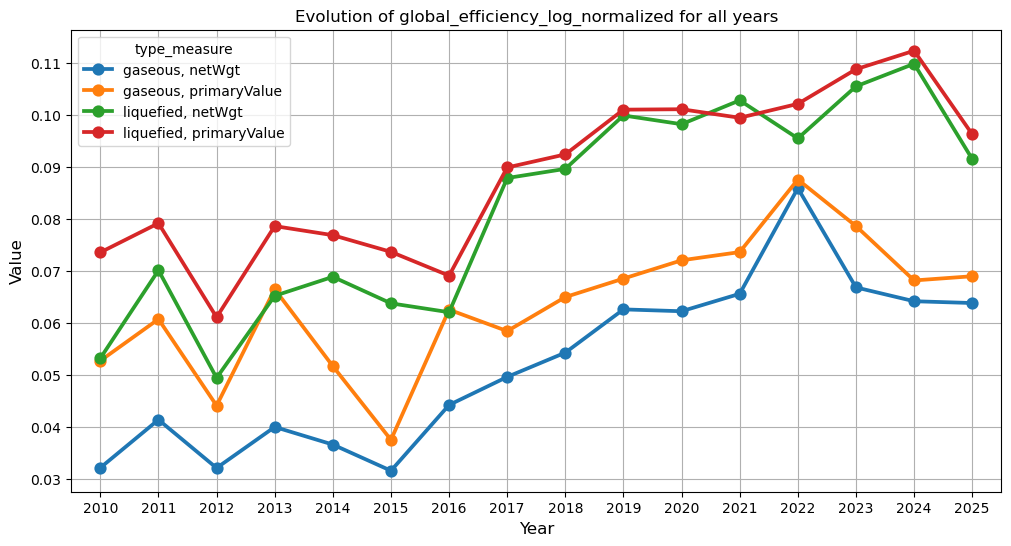

In [80]:
plot_metric("global_efficiency_log_normalized")

Logarithmically normalized efficiency shows a much better picture: efficiency is rising over the long period. However, after 2022, the gaseous type shows a reverse tendency after the disruption in Russia-EU trade. 
Log-efficiency showing better results supports the assumption of a discrepancy between the topology of the network and characteristics adjusted to weight. Major countries in the network does not increase efficiency through their trade; on the contrary, they decrease it, as large trades are too concentrated.

We should not forget that this efficiency logarithmically normalizes: the real world is not. But it again shows the problem is not in the distribution of edges but in the distribution of trades.

In [81]:
df_metrics[list(df_metrics.columns[3:-1:])].corr()

function,average_clustering,degree_assortativity_coefficient,density,global_efficiency,global_efficiency_log_normalized,reciprocity
function,,,,,,
average_clustering,1.000000,-0.138233,0.184375,0.065337,0.192588,-0.398630
degree_assortativity_coefficient,-0.138233,1.000000,-0.505646,0.078280,-0.507200,0.353218
density,0.184375,-0.505646,1.000000,-0.127531,0.921785,-0.379097
global_efficiency,0.065337,0.078280,-0.127531,1.000000,-0.132045,0.172816
global_efficiency_log_normalized,0.192588,-0.507200,0.921785,-0.132045,1.000000,-0.361310
reciprocity,-0.398630,0.353218,-0.379097,0.172816,-0.361310,1.000000


Correlations between metrics are not high (small sample). However, the correlation between global_efficiency_log_normalized and density is higher than 0.9, which implies that more connections between countries generally increase the speed of information sharing in the network. However, the sample is not large enough to conclude something.

In [82]:
def get_centralities(graphs: dict, func: nx.function, gas_type: str, measure: str, year: int) -> pd.DataFrame:

    """
    This function calculates centralities of each country in the given graph and returns a df with countries as indices.
    Inputs: function in networkx for centrality calculation, type of gas, type of measure, and year of observation.
    Output: df with countries as indices and a corresponding centrality value. 
    """
    
    G = graphs[gas_type][measure][f"G_{year}"]

    if func.__name__ == "pagerank": # for this function changing direction gives more meaningful results

        G_reversed = G.reverse() 
        centralities = func(G_reversed, weight=measure, alpha=0.85)

    elif func.__name__ == "katz_centrality_numpy":
        for u, v, d in G.edges(data=True):
            d["log_weight"] = np.log1p(d["primaryValue"])
            centralities = func(G, weight="log_weight", alpha = 0.06)
    
    else:
        centralities = func(G, weight=measure)

        
    df = pd.DataFrame(data = {func.__name__: centralities.values()}, index = centralities.keys())
    
    return df

In [83]:
def build_centralities_df(graphs: dict, gas_type: str, measure: str, year: int):
    """
    This function prints top countries for each centrality for a given type of gas, measure and year.
    """

    centralities_list = [nx.pagerank, nx.constraint, nx.katz_centrality_numpy]
    df_list = []

    for func in centralities_list:
        df = get_centralities(graphs = graphs, func=func, gas_type = gas_type, measure = measure, year=year)
        df_list.append(df)

    dfs_centr = pd.concat(df_list, axis=1)
    ddr = []
    for centrality in ["pagerank", "katz_centrality_numpy"]:
        ddr.append(dfs_centr[centrality].nlargest(5).reset_index())
        
    ddr.append(dfs_centr["constraint"].nsmallest(5).reset_index())
    top_countries = pd.concat(ddr, axis=1)
    top_countries.columns = ["pagerank_top", "pagerank_value", "katz_top", "katz_value", "constraint_top", "constraint_value"]
    return top_countries

In [84]:
build_centralities_df(graphs=graphs, gas_type="gaseous", measure="primaryValue", year=2024)

,pagerank_top,pagerank_value,katz_top,katz_value,constraint_top,constraint_value
0,United States of America,0.189920,Argentina,0.439589,Russian Federation,0.221608
1,Canada,0.163756,Chile,0.423933,Italy,0.259839
2,Norway,0.068310,Uruguay,0.385440,Bulgaria,0.267146
3,Sweden,0.059938,Singapore,0.355396,Norway,0.279709
4,Denmark,0.046738,Indonesia,0.194707,Australia,0.284374


In [85]:
build_centralities_df(graphs=graphs, gas_type="liquefied", measure="primaryValue", year=2024)

,pagerank_top,pagerank_value,katz_top,katz_value,constraint_top,constraint_value
0,United States of America,0.113775,Barbados,0.524708,United States of America,0.086573
1,South Africa,0.097707,Dominican Republic,0.434700,Equatorial Guinea,0.101003
2,Mozambique,0.094643,Guyana,0.284921,Angola,0.108875
3,Trinidad and Tobago,0.057610,Brazil,0.182056,Nigeria,0.116746
4,Malaysia,0.049531,Argentina,0.181659,Thailand,0.133181


The lower constraint - the better "broker" you are - you connect countries that are not connected, so you are important in their relationships. Pagerank and katz centrality find the "popular" nodes. We see that the most important country for liquefied gas is USA, which is expected. However, South Africa and Mozambique have even higher pagerank centrality. For gaseous type USA is top by pagerank, but this position is not supported by other metrics. We see different countries in tops for different metrics - generally, gas does not have one permanent leader in trades - usually big exporters and importers have large influence only on some regions, which makes their importance limited by the size of their region.

Final discussion:
1. Throughout history, liquified gas has shown higher clustering - it has been traded more internationally compared to direct pipes from producers to consumers of gaseous natural gas. However, in 2020-2021, the situation reversed abruptly, which indicates the "narrowing" of the market - the globalization of trade reduced.
2. Liquified gas permanently shows higher density, which is expected due to its higher internationalization. In recent years, we have seen a growing density for both types of gas, which could indicate growing globalization. However, the weighted metrics do not show the trend toward higher interconnectedness. So, despite the network"s topology is improving, we cannot say the same about the weighted graph (!).
3. We do not see the rising efficiency for both types of gas: only temporary spikes can be noticed. Logarithmically normalized efficiency is rising over the long period. However, after 2022, the gaseous type shows a reverse tendency because of the disruption in Russia-EU trade. 
Major countries in the network does not increase efficiency through their trade; on the contrary, they decrease it, as large trades are too concentrated.
4. Centrality metrics do not show a single leader of the network; however, the most important countries are usually the USA and Russian Federation, and Canada for gaseous type of gas and the USA, South Africa and Mozambique for liquified type.

Thank you for your attention! It was a long journey.